Baseline peak-lock metrics:
   channel  alpha_min  alpha_at_peak  alpha_max  peak_fraction  dist_to_min  \
0       C3   0.765867       0.882090   0.882090       1.000000     0.116223   
1       C4   0.756056       0.864513   0.864513       1.000000     0.108457   
2      CP1   0.694686       0.862500   0.862500       1.000000     0.167814   
3      CP2   0.732067       0.945807   0.945807       1.000000     0.213740   
4      CP5   0.748152       0.810350   0.866648       0.524899     0.062198   
5      CP6   0.794090       0.861600   0.948815       0.436323     0.067510   
6       Cz   0.771201       0.889686   0.889686       1.000000     0.118485   
7       F3   0.813601       0.884610   0.884761       0.997880     0.071009   
8       F4   0.854307       0.946370   0.967664       0.812153     0.092064   
9       F7   0.808386       0.879728   0.879728       1.000000     0.071342   
10      F8   0.843007       0.887478   0.917111       0.600111     0.044471   
11     FC1   0.791435   

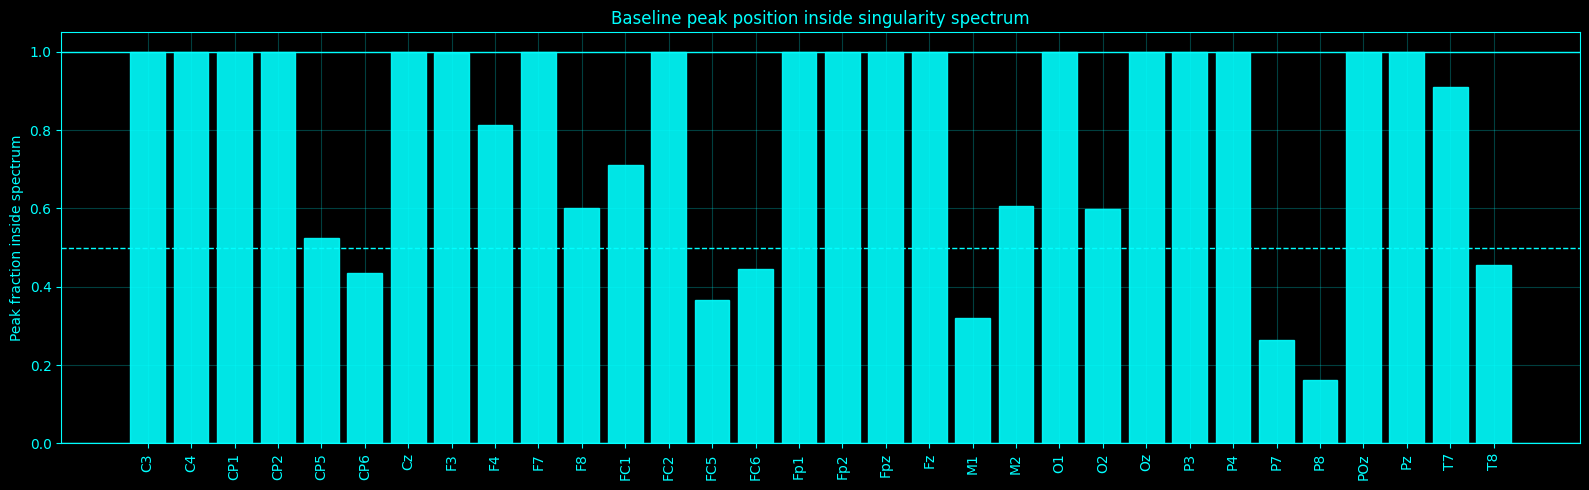

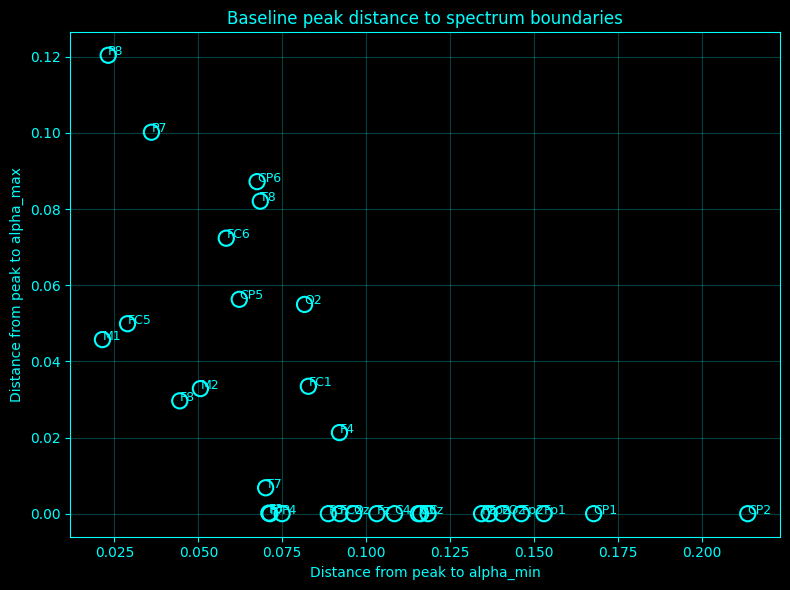

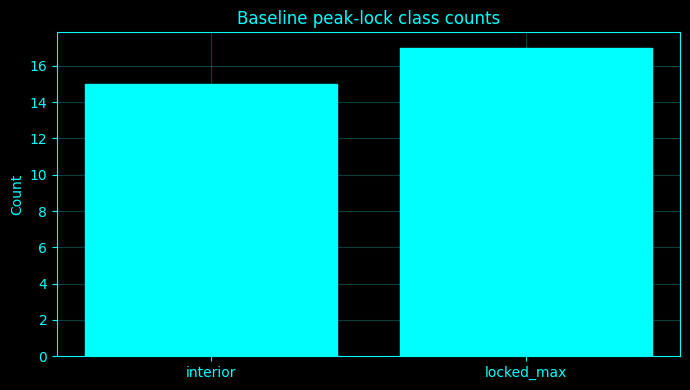

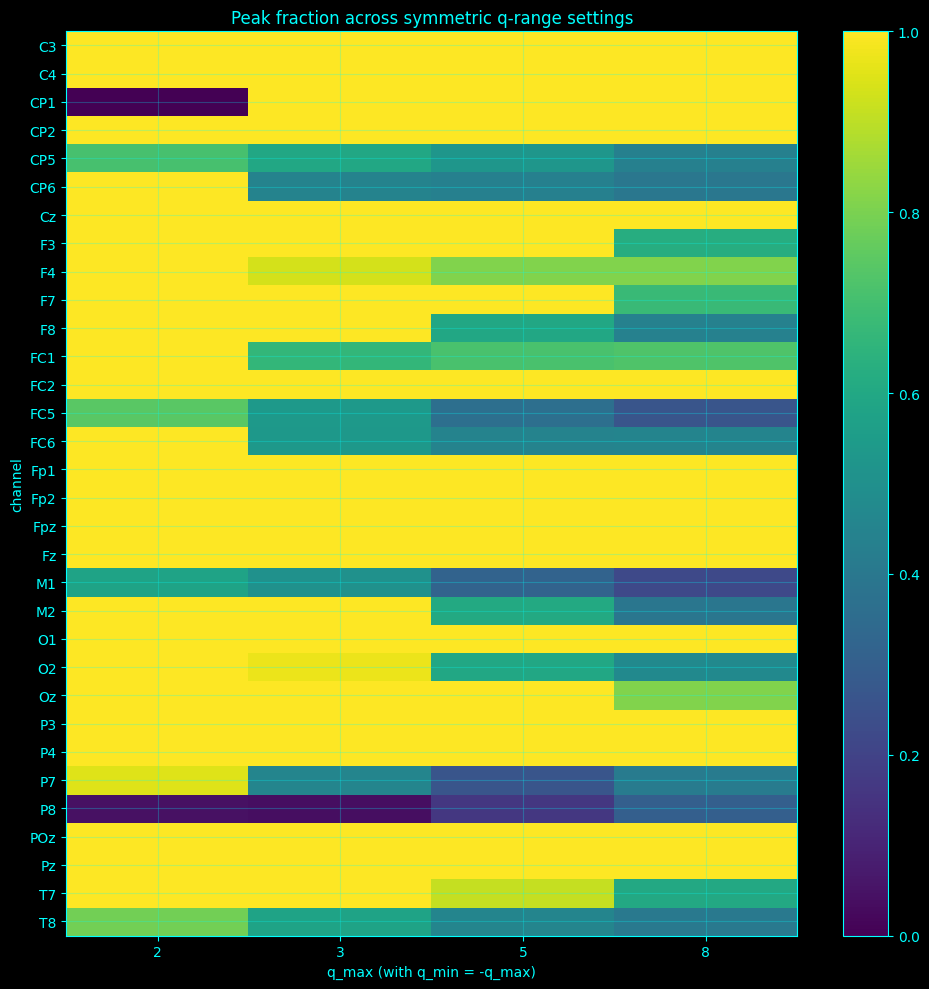

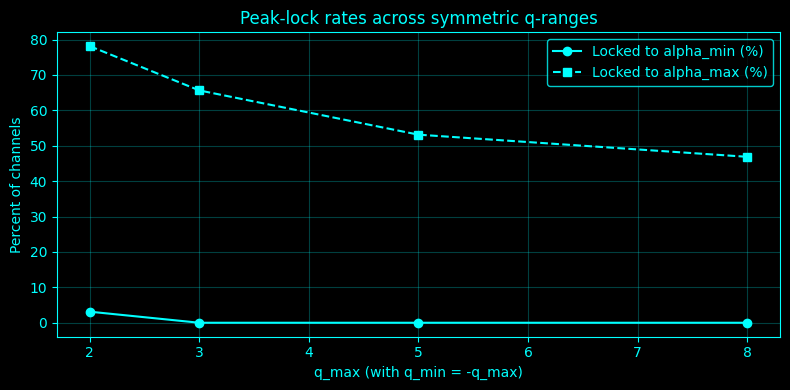

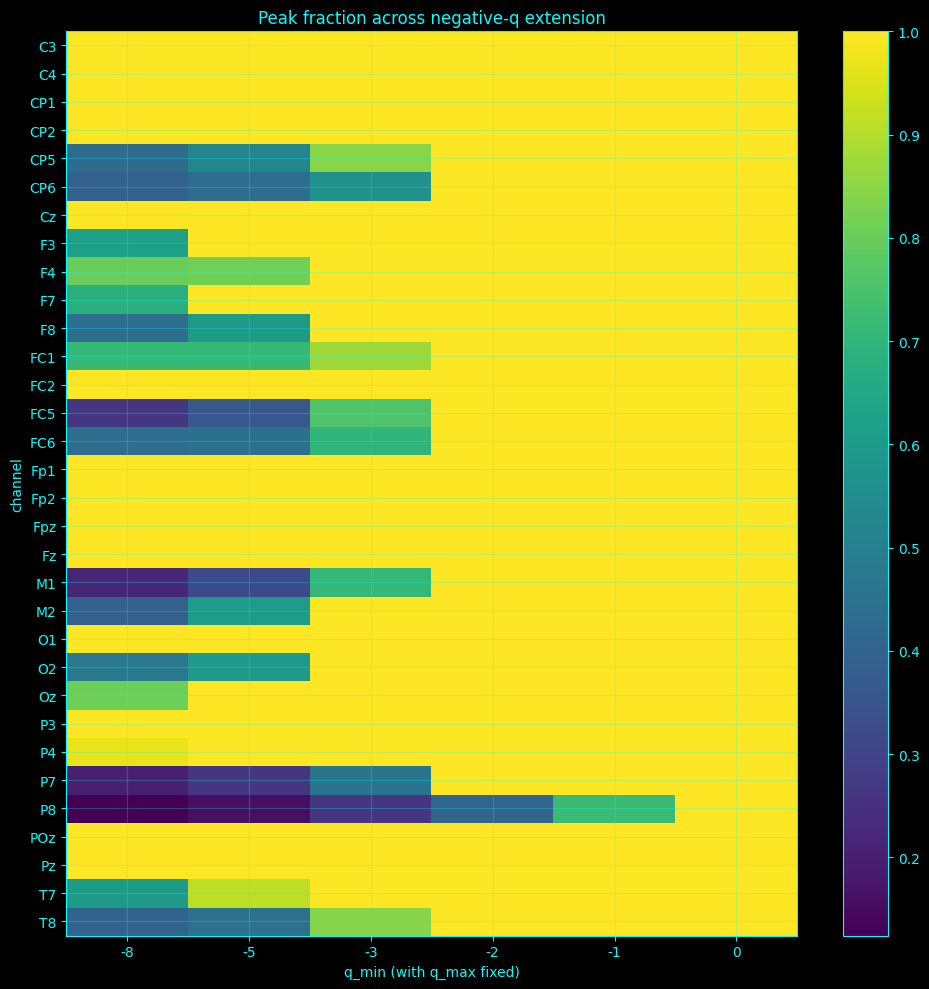

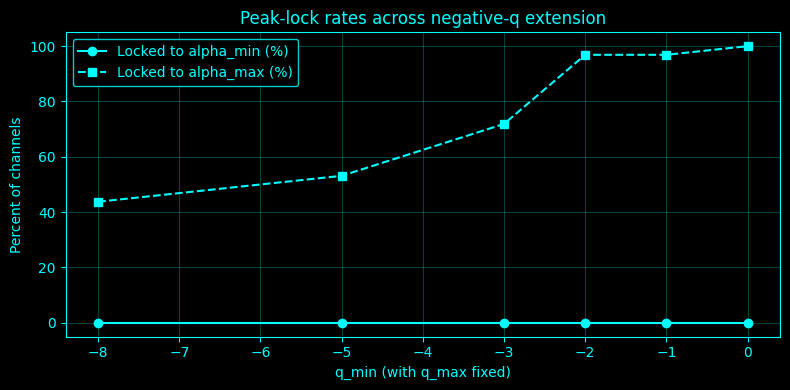

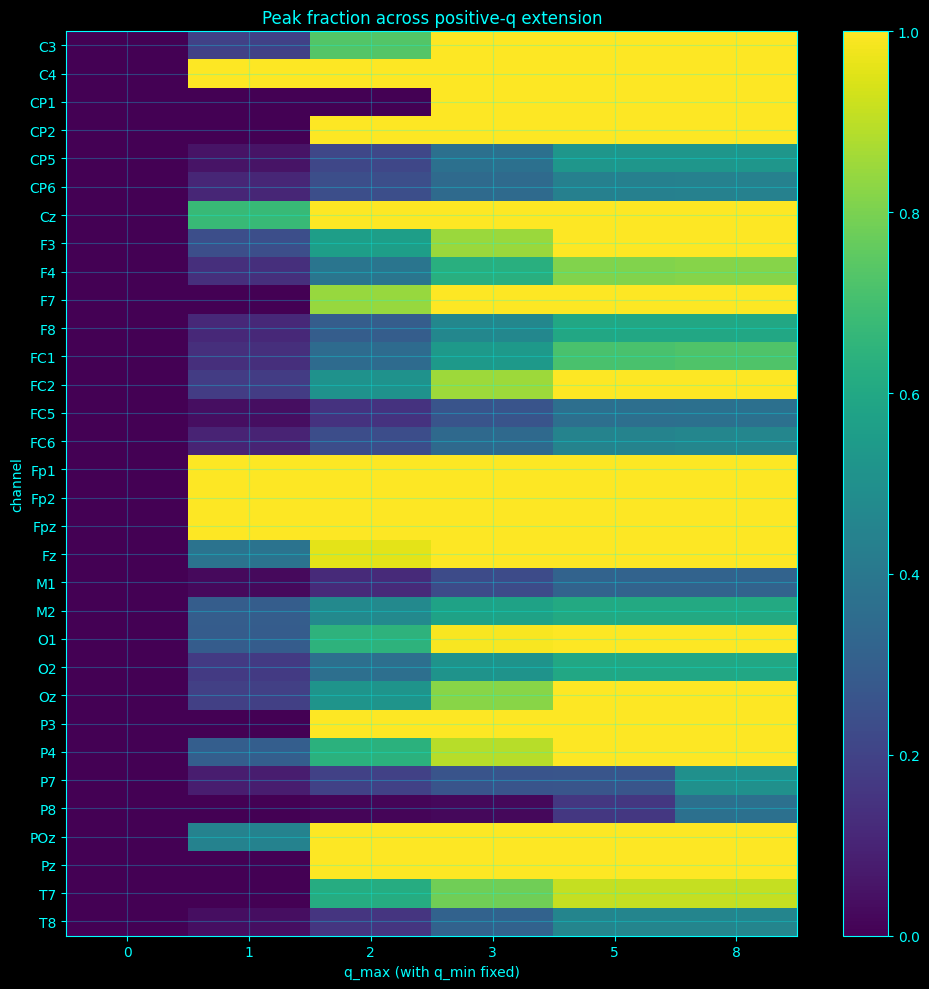

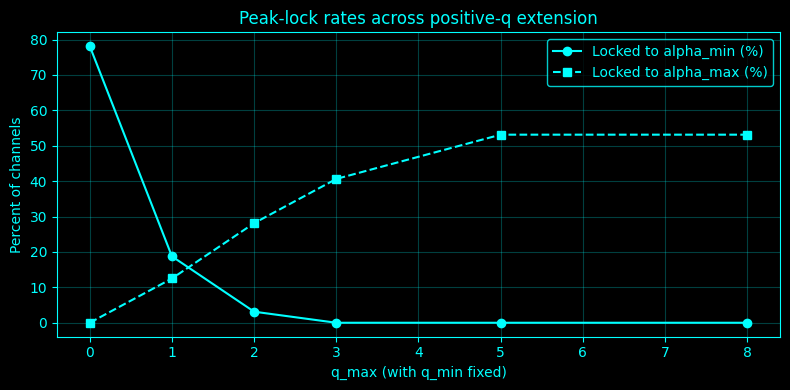


Channel-wise lock rates across studies:
   channel  mean_peak_fraction  locked_min_rate  locked_max_rate  \
0       C3              0.8780           5.8824          82.3529   
1       C4              0.9412           5.8824          94.1176   
2      CP1              0.7647          23.5294          76.4706   
3      CP2              0.8824          11.7647          88.2353   
4      CP5              0.5461           5.8824          17.6471   
5      CP6              0.5108           5.8824          23.5294   
6       Cz              0.9221           5.8824          88.2353   
7       F3              0.8167           5.8824          35.2941   
8       F4              0.7510           5.8824          29.4118   
9       F7              0.8356          11.7647          70.5882   
10      F8              0.6328           0.0000          35.2941   
11     FC1              0.6803           0.0000          23.5294   
12     FC2              0.8552           0.0000          76.4706   
13     

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

baseline_summary_path = os.path.join(
    base_dir, "mfdfa_manual_spectrum_results", "mfdfa_manual_spectrum_summary.csv"
)
qrange_summary_path = os.path.join(
    base_dir, "mfdfa_qrange_sensitivity", "qrange_sensitivity_summary.csv"
)
negq_summary_path = os.path.join(
    base_dir, "mfdfa_negative_q_stability", "negative_q_stability_summary.csv"
)
posq_summary_path = os.path.join(
    base_dir, "mfdfa_positive_q_dominance", "positive_q_dominance_summary.csv"
)

out_dir = os.path.join(base_dir, "mfdfa_peak_locking_analysis")
os.makedirs(out_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# PEAK-LOCK HELPERS
# -------------------------------------------------------
def add_peak_lock_metrics(df, atol=1e-8):
    df = df.copy()

    required = {"channel", "alpha_min", "alpha_max", "alpha_at_peak"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["alpha_width_recomputed"] = df["alpha_max"] - df["alpha_min"]
    df["left_width"] = df["alpha_at_peak"] - df["alpha_min"]
    df["right_width"] = df["alpha_max"] - df["alpha_at_peak"]

    denom = np.maximum(df["alpha_width_recomputed"].to_numpy(dtype=float), 1e-12)
    df["peak_fraction"] = df["left_width"] / denom

    df["dist_to_min"] = np.abs(df["alpha_at_peak"] - df["alpha_min"])
    df["dist_to_max"] = np.abs(df["alpha_max"] - df["alpha_at_peak"])

    df["peak_locked_min"] = np.isclose(
        df["alpha_at_peak"].to_numpy(dtype=float),
        df["alpha_min"].to_numpy(dtype=float),
        atol=atol,
        rtol=0.0
    )
    df["peak_locked_max"] = np.isclose(
        df["alpha_at_peak"].to_numpy(dtype=float),
        df["alpha_max"].to_numpy(dtype=float),
        atol=atol,
        rtol=0.0
    )

    def classify_row(row):
        if row["peak_locked_min"] and row["peak_locked_max"]:
            return "collapsed"
        if row["peak_locked_min"]:
            return "locked_min"
        if row["peak_locked_max"]:
            return "locked_max"
        return "interior"

    df["peak_class"] = df.apply(classify_row, axis=1)
    return df

def save_table(df, path):
    df.to_csv(path, index=False)

def heatmap_plot(pivot_df, title, xlabel, ylabel, save_path):
    fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(pivot_df.values, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_xticklabels([str(c) for c in pivot_df.columns], color=ACCENT)
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_yticklabels(list(pivot_df.index), color=ACCENT)

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# LOAD BASELINE SUMMARY
# -------------------------------------------------------
baseline_df = pd.read_csv(baseline_summary_path)
baseline_df = add_peak_lock_metrics(baseline_df)
baseline_df = baseline_df.sort_values("channel").reset_index(drop=True)

baseline_csv = os.path.join(out_dir, "baseline_peak_lock_metrics.csv")
save_table(baseline_df, baseline_csv)

print("Baseline peak-lock metrics:")
print(baseline_df[[
    "channel", "alpha_min", "alpha_at_peak", "alpha_max",
    "peak_fraction", "dist_to_min", "dist_to_max",
    "peak_locked_min", "peak_locked_max", "peak_class"
]].round(6))

# -------------------------------------------------------
# 1) BASELINE PEAK FRACTION BAR PLOT
# -------------------------------------------------------
x = np.arange(len(baseline_df))

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
style_ax(ax)

ax.bar(x, baseline_df["peak_fraction"], color=ACCENT, edgecolor=ACCENT, alpha=0.9)
ax.axhline(0.0, color=ACCENT, linewidth=1.0)
ax.axhline(0.5, color=ACCENT, linewidth=1.0, linestyle="--")
ax.axhline(1.0, color=ACCENT, linewidth=1.0)

ax.set_xticks(x)
ax.set_xticklabels(baseline_df["channel"], rotation=90)
ax.set_ylabel("Peak fraction inside spectrum")
ax.set_title("Baseline peak position inside singularity spectrum")

peak_fraction_path = os.path.join(out_dir, "baseline_peak_fraction_bar.png")
plt.tight_layout()
plt.savefig(peak_fraction_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 2) BASELINE DISTANCE TO BOUNDARIES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
style_ax(ax)

ax.scatter(
    baseline_df["dist_to_min"],
    baseline_df["dist_to_max"],
    s=120,
    facecolors="none",
    edgecolors=ACCENT,
    linewidths=1.5
)

for _, row in baseline_df.iterrows():
    ax.text(row["dist_to_min"], row["dist_to_max"], row["channel"], fontsize=9, color=ACCENT)

ax.set_xlabel("Distance from peak to alpha_min")
ax.set_ylabel("Distance from peak to alpha_max")
ax.set_title("Baseline peak distance to spectrum boundaries")

dist_scatter_path = os.path.join(out_dir, "baseline_peak_distance_scatter.png")
plt.tight_layout()
plt.savefig(dist_scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 3) BASELINE CLASS COUNTS
# -------------------------------------------------------
class_counts = baseline_df["peak_class"].value_counts().sort_index()
class_counts_csv = os.path.join(out_dir, "baseline_peak_class_counts.csv")
class_counts.to_csv(class_counts_csv, header=["count"])

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
style_ax(ax)

ax.bar(class_counts.index, class_counts.values, color=ACCENT, edgecolor=ACCENT)
ax.set_ylabel("Count")
ax.set_title("Baseline peak-lock class counts")

class_count_path = os.path.join(out_dir, "baseline_peak_class_counts.png")
plt.tight_layout()
plt.savefig(class_count_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# 4) SYMMETRIC Q-RANGE PEAK-LOCK ANALYSIS
# -------------------------------------------------------
if os.path.exists(qrange_summary_path):
    qrange_df = pd.read_csv(qrange_summary_path)
    qrange_df = add_peak_lock_metrics(qrange_df)

    # Use q_max as symmetric range index
    qrange_df["q_extent"] = qrange_df["q_max"]

    qrange_csv = os.path.join(out_dir, "qrange_peak_lock_metrics.csv")
    save_table(qrange_df, qrange_csv)

    # Heatmap: peak fraction by channel x q_extent
    qrange_pivot = qrange_df.pivot_table(
        index="channel",
        columns="q_extent",
        values="peak_fraction",
        aggfunc="mean"
    ).sort_index(axis=1)
    qrange_heatmap_path = os.path.join(out_dir, "qrange_peak_fraction_heatmap.png")
    heatmap_plot(
        qrange_pivot,
        "Peak fraction across symmetric q-range settings",
        "q_max (with q_min = -q_max)",
        "channel",
        qrange_heatmap_path
    )

    # Lock rates by q_extent
    qrange_rates = qrange_df.groupby("q_extent")[["peak_locked_min", "peak_locked_max"]].mean().reset_index()
    qrange_rates["peak_locked_min"] *= 100.0
    qrange_rates["peak_locked_max"] *= 100.0
    qrange_rates_csv = os.path.join(out_dir, "qrange_peak_lock_rates.csv")
    qrange_rates.to_csv(qrange_rates_csv, index=False)

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
    style_ax(ax)
    ax.plot(qrange_rates["q_extent"], qrange_rates["peak_locked_min"],
            marker='o', color=ACCENT, label="Locked to alpha_min (%)")
    ax.plot(qrange_rates["q_extent"], qrange_rates["peak_locked_max"],
            marker='s', color=ACCENT, linestyle="--", label="Locked to alpha_max (%)")
    ax.set_xlabel("q_max (with q_min = -q_max)")
    ax.set_ylabel("Percent of channels")
    ax.set_title("Peak-lock rates across symmetric q-ranges")
    ax.legend()

    qrange_rates_path = os.path.join(out_dir, "qrange_peak_lock_rates.png")
    plt.tight_layout()
    plt.savefig(qrange_rates_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# 5) NEGATIVE-Q PEAK-LOCK ANALYSIS
# -------------------------------------------------------
if os.path.exists(negq_summary_path):
    negq_df = pd.read_csv(negq_summary_path)
    negq_df = add_peak_lock_metrics(negq_df)

    negq_csv = os.path.join(out_dir, "negative_q_peak_lock_metrics.csv")
    save_table(negq_df, negq_csv)

    negq_pivot = negq_df.pivot_table(
        index="channel",
        columns="q_min",
        values="peak_fraction",
        aggfunc="mean"
    ).sort_index(axis=1)

    negq_heatmap_path = os.path.join(out_dir, "negative_q_peak_fraction_heatmap.png")
    heatmap_plot(
        negq_pivot,
        "Peak fraction across negative-q extension",
        "q_min (with q_max fixed)",
        "channel",
        negq_heatmap_path
    )

    negq_rates = negq_df.groupby("q_min")[["peak_locked_min", "peak_locked_max"]].mean().reset_index()
    negq_rates["peak_locked_min"] *= 100.0
    negq_rates["peak_locked_max"] *= 100.0
    negq_rates_csv = os.path.join(out_dir, "negative_q_peak_lock_rates.csv")
    negq_rates.to_csv(negq_rates_csv, index=False)

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
    style_ax(ax)
    ax.plot(negq_rates["q_min"], negq_rates["peak_locked_min"],
            marker='o', color=ACCENT, label="Locked to alpha_min (%)")
    ax.plot(negq_rates["q_min"], negq_rates["peak_locked_max"],
            marker='s', color=ACCENT, linestyle="--", label="Locked to alpha_max (%)")
    ax.set_xlabel("q_min (with q_max fixed)")
    ax.set_ylabel("Percent of channels")
    ax.set_title("Peak-lock rates across negative-q extension")
    ax.legend()

    negq_rates_path = os.path.join(out_dir, "negative_q_peak_lock_rates.png")
    plt.tight_layout()
    plt.savefig(negq_rates_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# 6) POSITIVE-Q PEAK-LOCK ANALYSIS
# -------------------------------------------------------
if os.path.exists(posq_summary_path):
    posq_df = pd.read_csv(posq_summary_path)
    posq_df = add_peak_lock_metrics(posq_df)

    posq_csv = os.path.join(out_dir, "positive_q_peak_lock_metrics.csv")
    save_table(posq_df, posq_csv)

    posq_pivot = posq_df.pivot_table(
        index="channel",
        columns="q_max",
        values="peak_fraction",
        aggfunc="mean"
    ).sort_index(axis=1)

    posq_heatmap_path = os.path.join(out_dir, "positive_q_peak_fraction_heatmap.png")
    heatmap_plot(
        posq_pivot,
        "Peak fraction across positive-q extension",
        "q_max (with q_min fixed)",
        "channel",
        posq_heatmap_path
    )

    posq_rates = posq_df.groupby("q_max")[["peak_locked_min", "peak_locked_max"]].mean().reset_index()
    posq_rates["peak_locked_min"] *= 100.0
    posq_rates["peak_locked_max"] *= 100.0
    posq_rates_csv = os.path.join(out_dir, "positive_q_peak_lock_rates.csv")
    posq_rates.to_csv(posq_rates_csv, index=False)

    fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
    style_ax(ax)
    ax.plot(posq_rates["q_max"], posq_rates["peak_locked_min"],
            marker='o', color=ACCENT, label="Locked to alpha_min (%)")
    ax.plot(posq_rates["q_max"], posq_rates["peak_locked_max"],
            marker='s', color=ACCENT, linestyle="--", label="Locked to alpha_max (%)")
    ax.set_xlabel("q_max (with q_min fixed)")
    ax.set_ylabel("Percent of channels")
    ax.set_title("Peak-lock rates across positive-q extension")
    ax.legend()

    posq_rates_path = os.path.join(out_dir, "positive_q_peak_lock_rates.png")
    plt.tight_layout()
    plt.savefig(posq_rates_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# 7) CHANNEL-WISE LOCK SUMMARY ACROSS ALL STUDIES
# -------------------------------------------------------
summary_rows = []

# baseline
for _, row in baseline_df.iterrows():
    summary_rows.append({
        "study": "baseline",
        "channel": row["channel"],
        "peak_class": row["peak_class"],
        "peak_fraction": row["peak_fraction"],
    })

if os.path.exists(qrange_summary_path):
    for _, row in qrange_df.iterrows():
        summary_rows.append({
            "study": "qrange",
            "channel": row["channel"],
            "peak_class": row["peak_class"],
            "peak_fraction": row["peak_fraction"],
        })

if os.path.exists(negq_summary_path):
    for _, row in negq_df.iterrows():
        summary_rows.append({
            "study": "negative_q",
            "channel": row["channel"],
            "peak_class": row["peak_class"],
            "peak_fraction": row["peak_fraction"],
        })

if os.path.exists(posq_summary_path):
    for _, row in posq_df.iterrows():
        summary_rows.append({
            "study": "positive_q",
            "channel": row["channel"],
            "peak_class": row["peak_class"],
            "peak_fraction": row["peak_fraction"],
        })

all_peak_df = pd.DataFrame(summary_rows)
all_peak_csv = os.path.join(out_dir, "all_studies_peak_lock_table.csv")
all_peak_df.to_csv(all_peak_csv, index=False)

lock_rate_by_channel = all_peak_df.groupby("channel").agg(
    mean_peak_fraction=("peak_fraction", "mean"),
    locked_min_rate=("peak_class", lambda s: np.mean(s == "locked_min")),
    locked_max_rate=("peak_class", lambda s: np.mean(s == "locked_max")),
    interior_rate=("peak_class", lambda s: np.mean(s == "interior")),
).reset_index()

lock_rate_by_channel["locked_min_rate"] *= 100.0
lock_rate_by_channel["locked_max_rate"] *= 100.0
lock_rate_by_channel["interior_rate"] *= 100.0

lock_rate_by_channel_csv = os.path.join(out_dir, "channel_peak_lock_rates_across_studies.csv")
lock_rate_by_channel.to_csv(lock_rate_by_channel_csv, index=False)

print("\nChannel-wise lock rates across studies:")
print(lock_rate_by_channel.round(4))

# -------------------------------------------------------
# 8) TOP MOST LOCKED CHANNELS
# -------------------------------------------------------
top_locked_max = lock_rate_by_channel.sort_values("locked_max_rate", ascending=False).head(10)
top_locked_min = lock_rate_by_channel.sort_values("locked_min_rate", ascending=False).head(10)
top_interior = lock_rate_by_channel.sort_values("interior_rate", ascending=False).head(10)

top_locked_max.to_csv(os.path.join(out_dir, "top_locked_max_channels.csv"), index=False)
top_locked_min.to_csv(os.path.join(out_dir, "top_locked_min_channels.csv"), index=False)
top_interior.to_csv(os.path.join(out_dir, "top_interior_peak_channels.csv"), index=False)

print("\nTop locked-max channels:")
print(top_locked_max.round(4))

print("\nTop locked-min channels:")
print(top_locked_min.round(4))

print("\nTop interior-peak channels:")
print(top_interior.round(4))

# -------------------------------------------------------
# 9) TEXT SUMMARY
# -------------------------------------------------------
txt_path = os.path.join(out_dir, "peak_locking_summary.txt")
with open(txt_path, "w") as f:
    f.write("Peak-locking analysis of multifractal spectra\n")
    f.write("============================================\n\n")
    f.write("Definitions:\n")
    f.write("peak_fraction = (alpha_at_peak - alpha_min) / (alpha_max - alpha_min)\n")
    f.write("locked_min: alpha_at_peak ≈ alpha_min\n")
    f.write("locked_max: alpha_at_peak ≈ alpha_max\n")
    f.write("interior: peak not locked to either boundary\n\n")

    baseline_counts = baseline_df["peak_class"].value_counts()
    f.write("Baseline peak-class counts:\n")
    for k, v in baseline_counts.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nTop locked-max channels across all studies:\n")
    for _, row in top_locked_max.iterrows():
        f.write(f"  {row['channel']}: {row['locked_max_rate']:.2f}%\n")

    f.write("\nTop locked-min channels across all studies:\n")
    for _, row in top_locked_min.iterrows():
        f.write(f"  {row['channel']}: {row['locked_min_rate']:.2f}%\n")

    f.write("\nTop interior-peak channels across all studies:\n")
    for _, row in top_interior.iterrows():
        f.write(f"  {row['channel']}: {row['interior_rate']:.2f}%\n")

print("\nSaved outputs to:", out_dir)
print("Baseline table:", baseline_csv)
print("All-studies table:", all_peak_csv)
print("Channel lock rates:", lock_rate_by_channel_csv)
print("Summary text:", txt_path)

Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec
Using scales: [    5     6     8    10    14    18    24    31    40    52    68    89
   116   151   196   255   331   431   560   727   945  1229  1597  2076
  2697  3506  4556  5921  7694 10000]


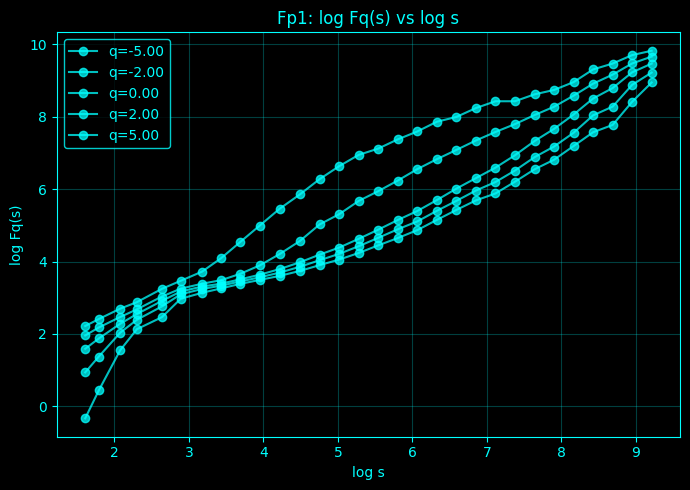

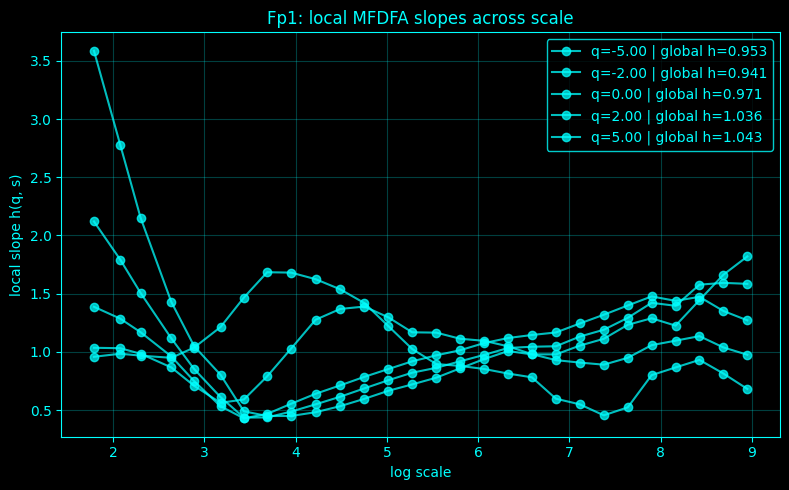

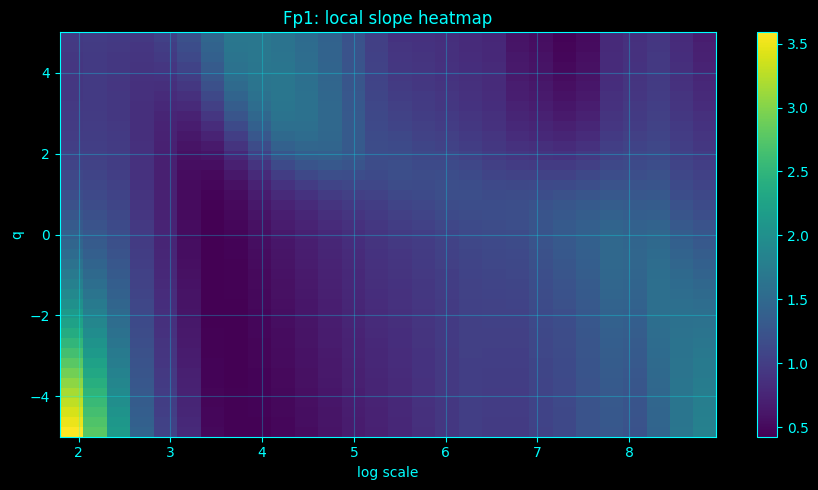

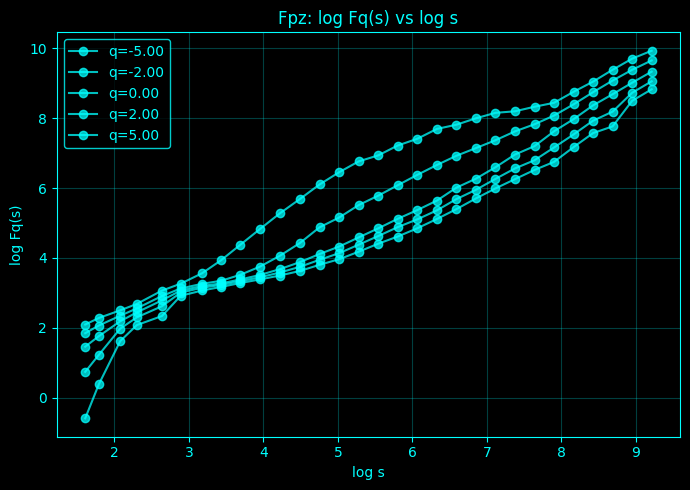

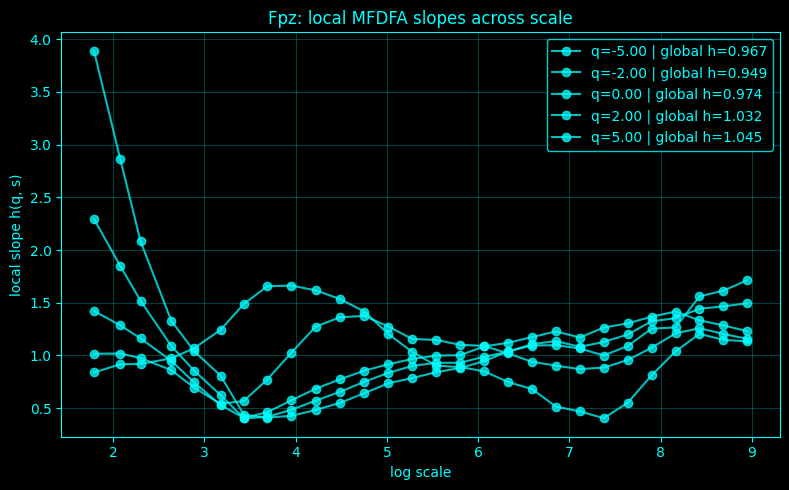

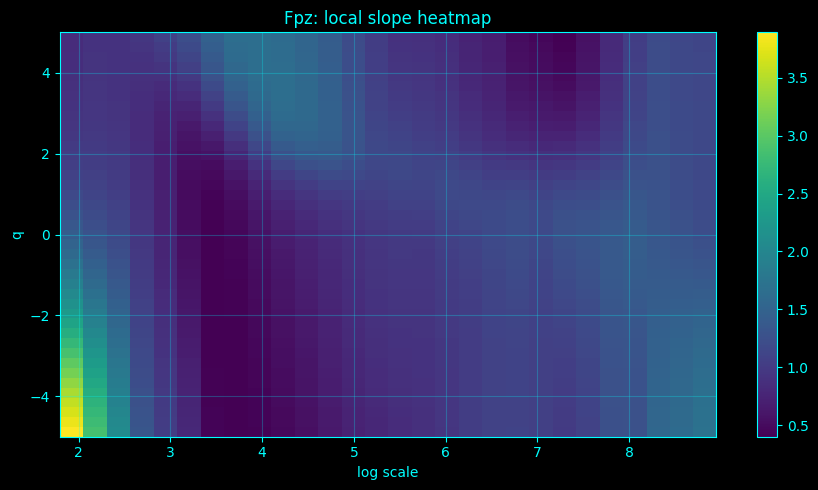

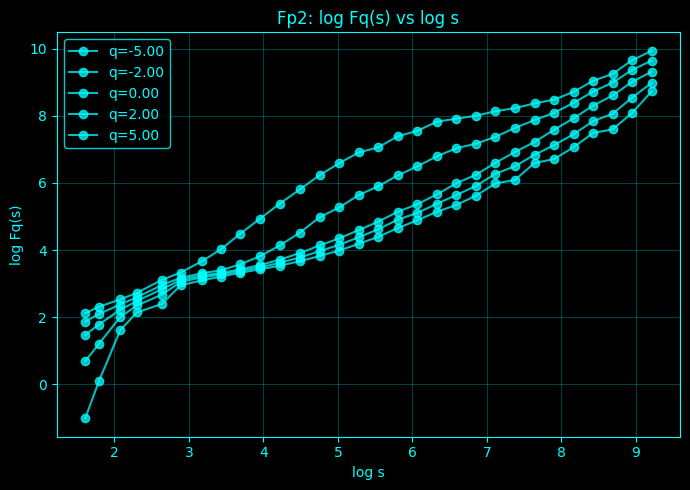

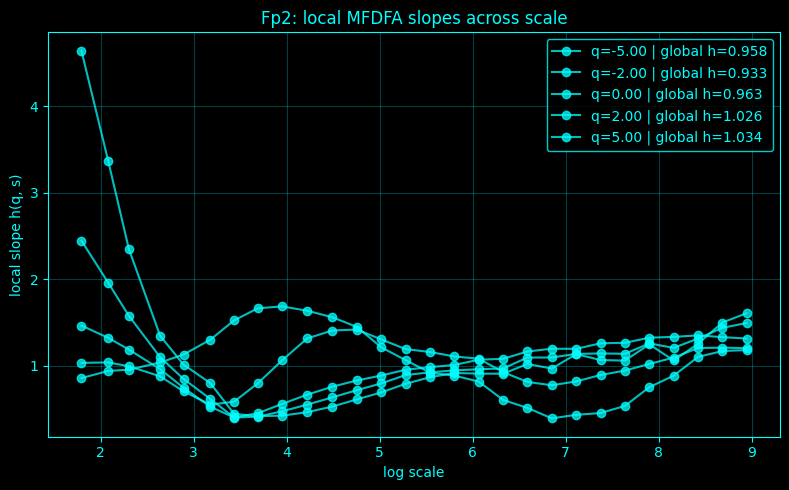

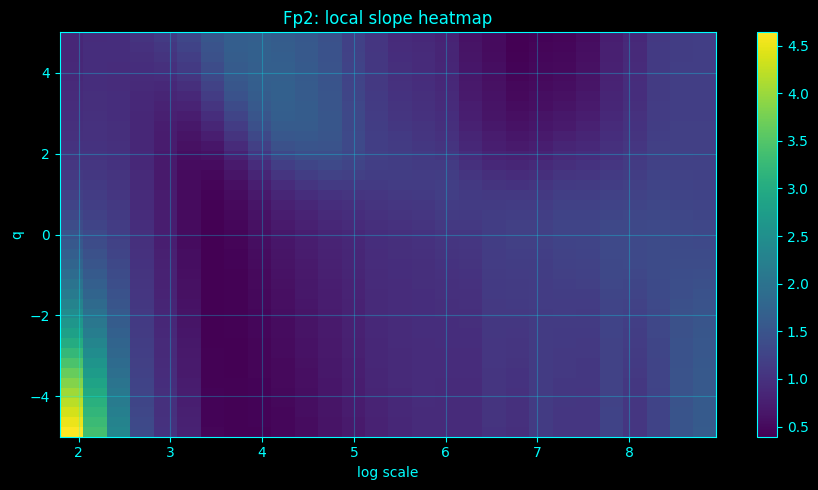

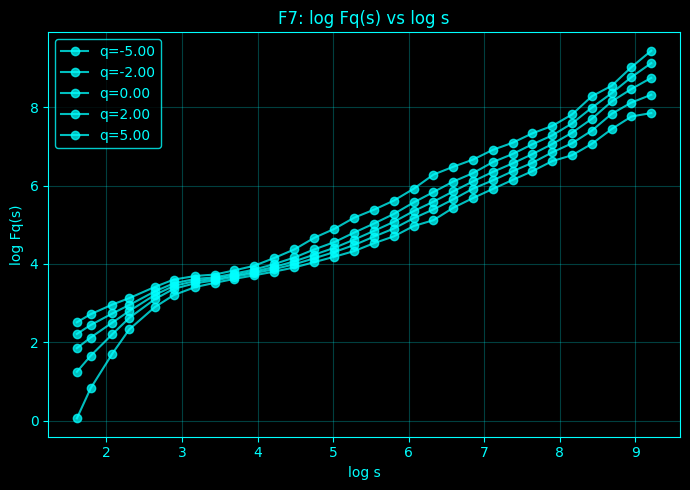

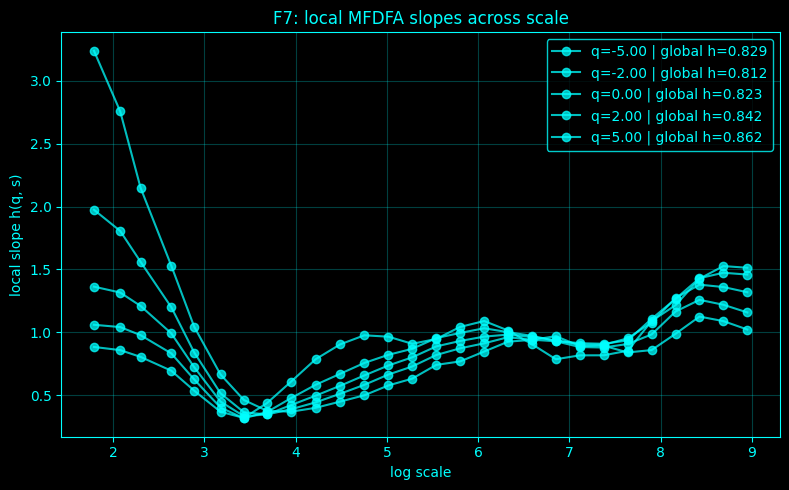

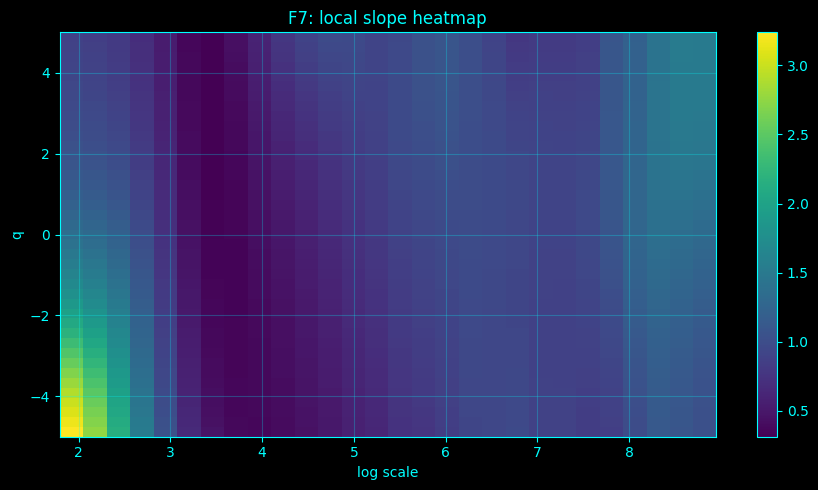

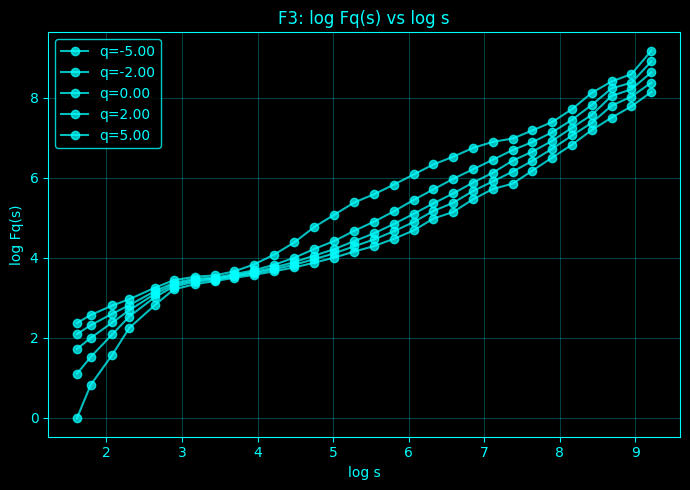

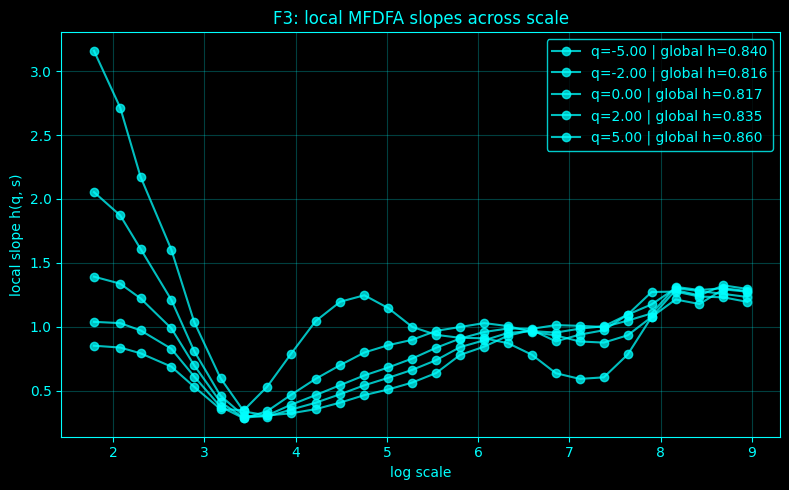

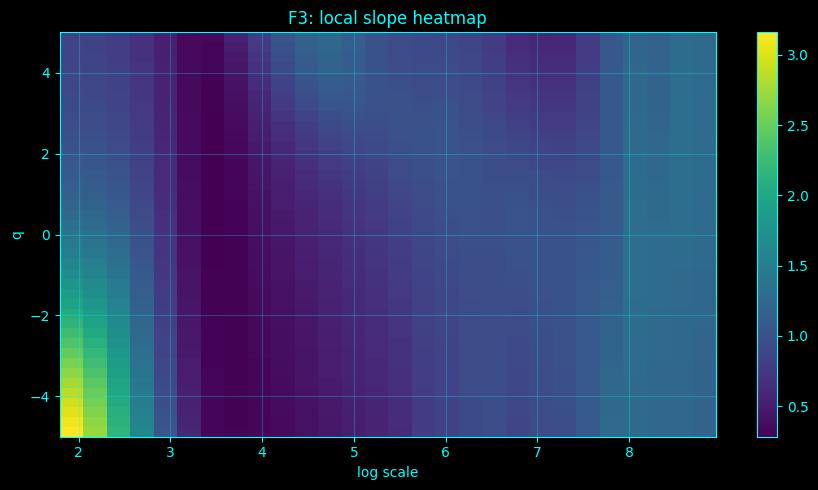

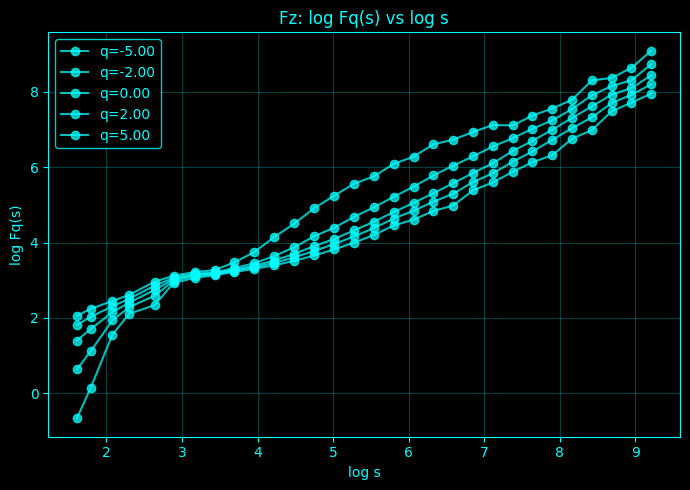

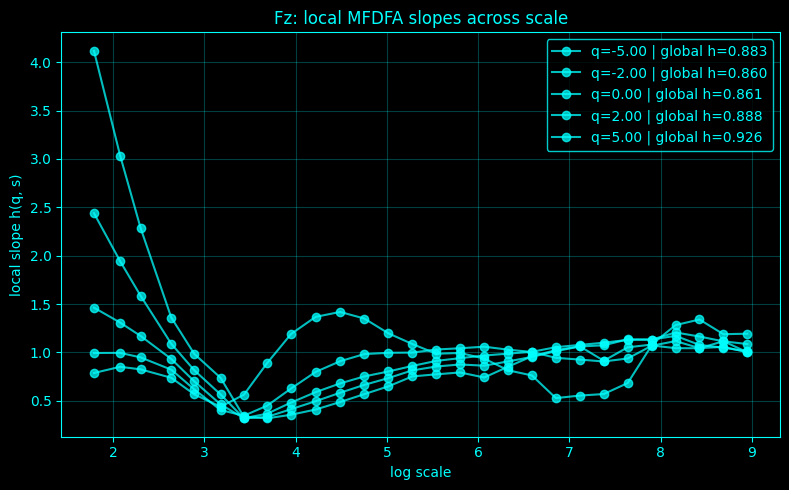

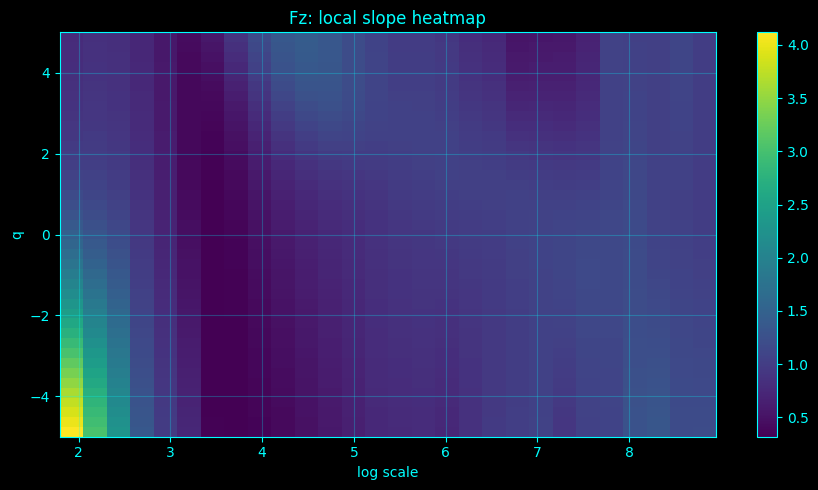

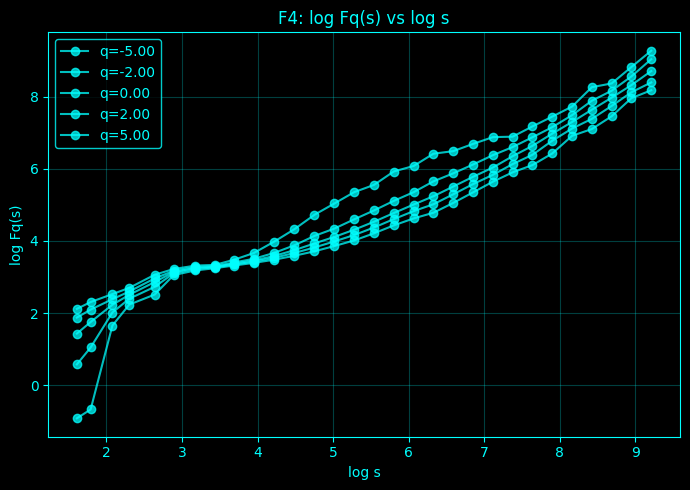

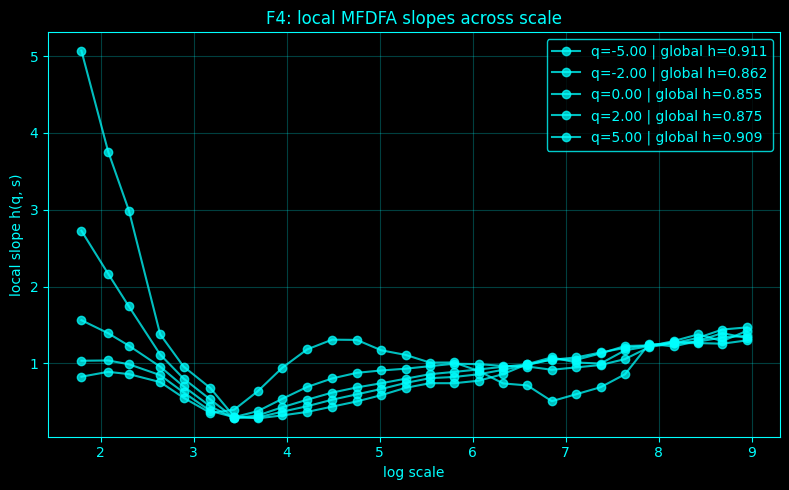

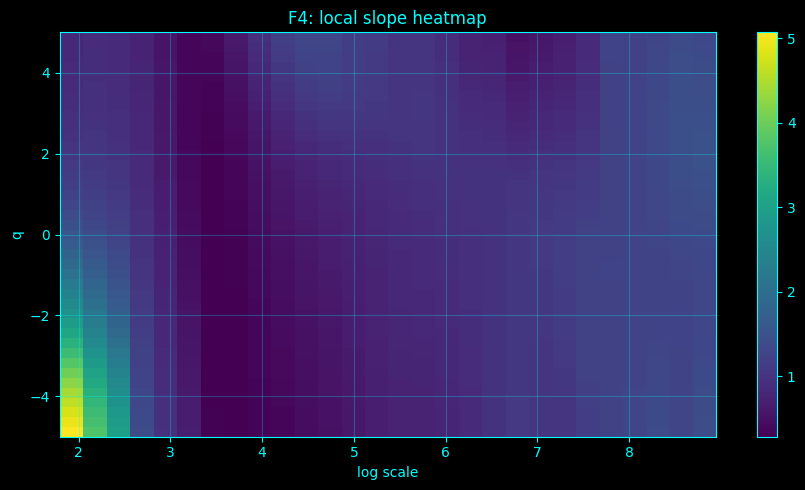

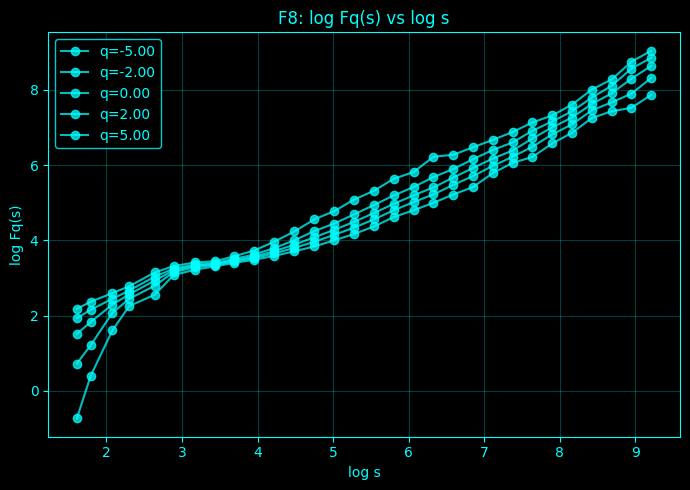

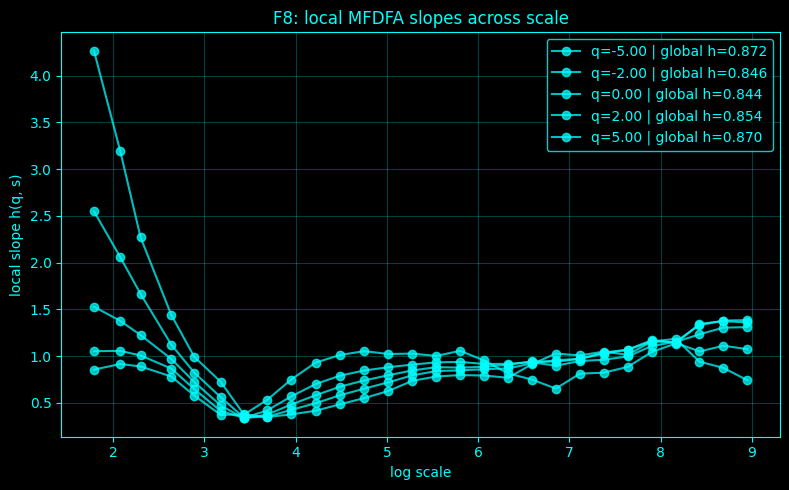

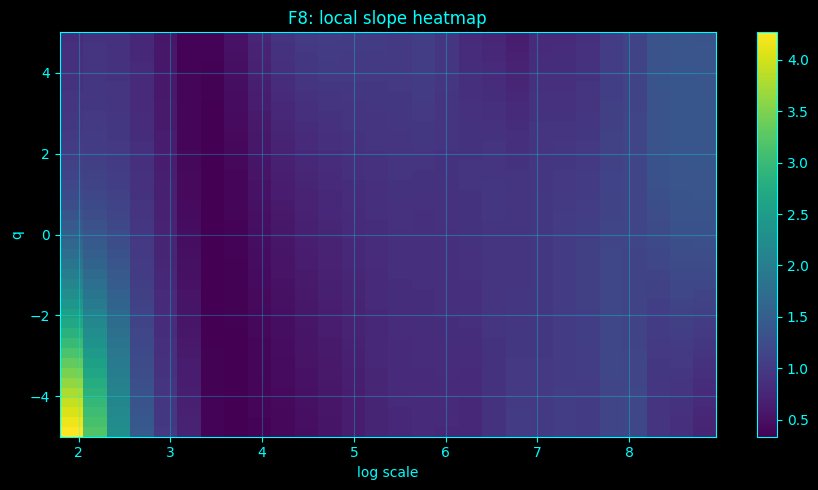

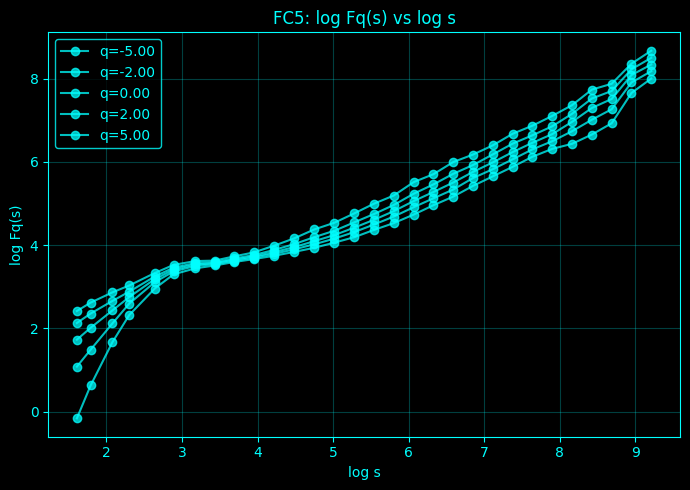

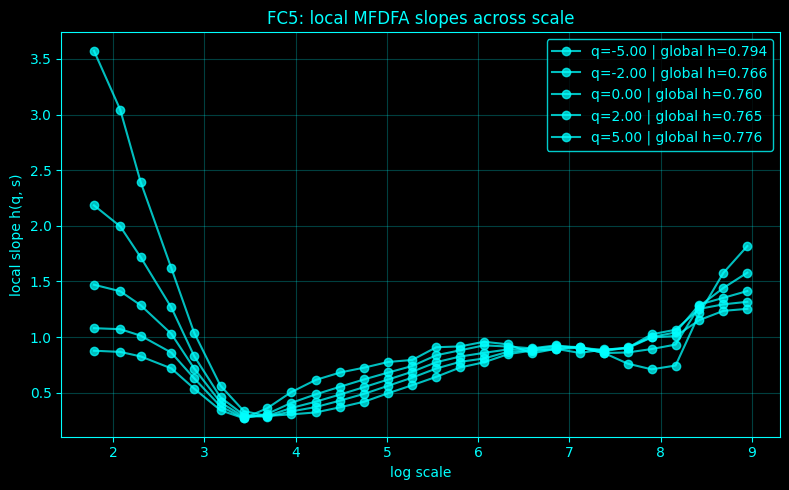

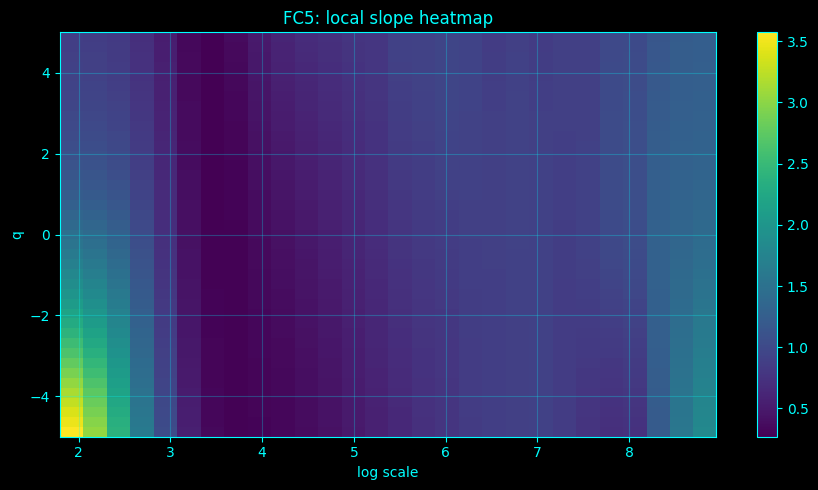

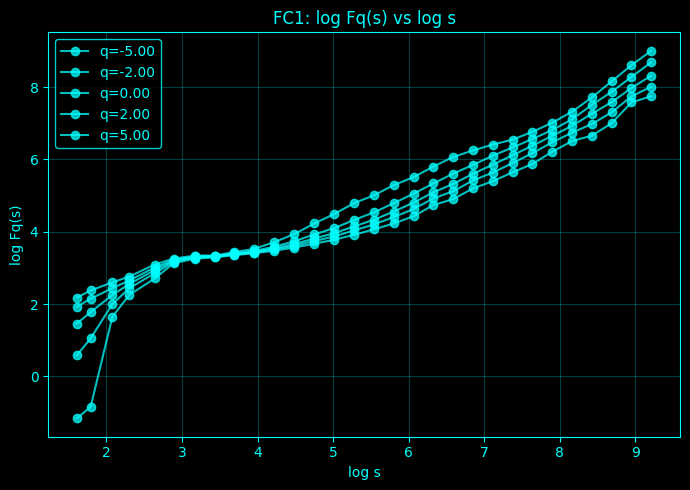

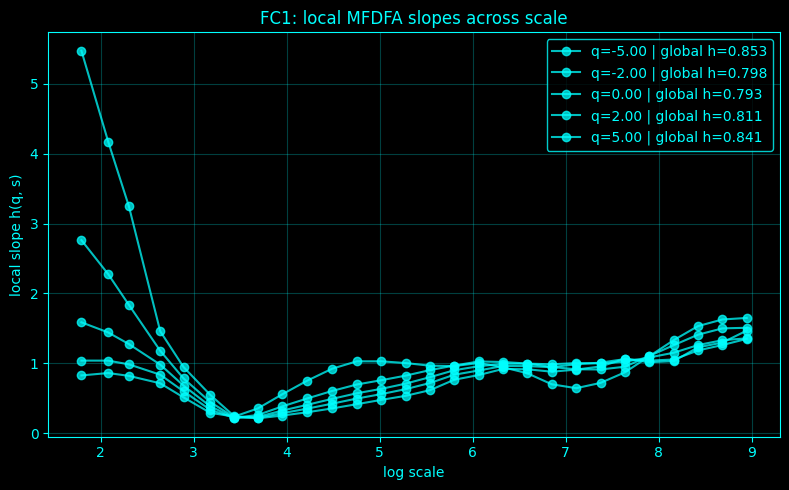

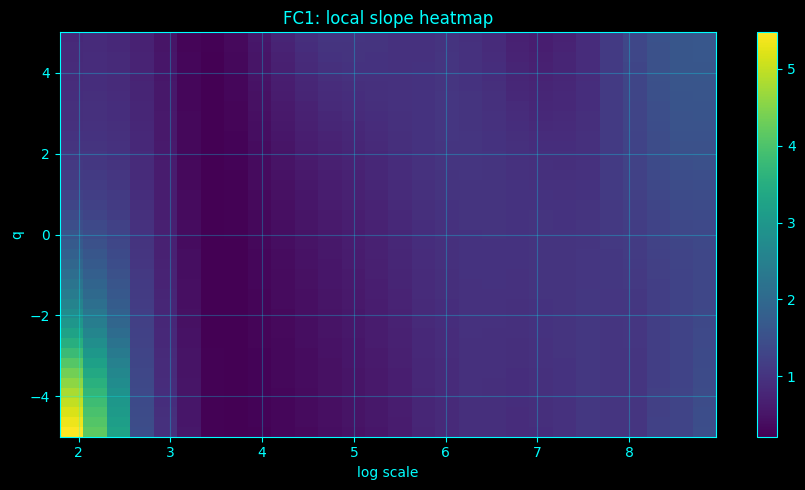

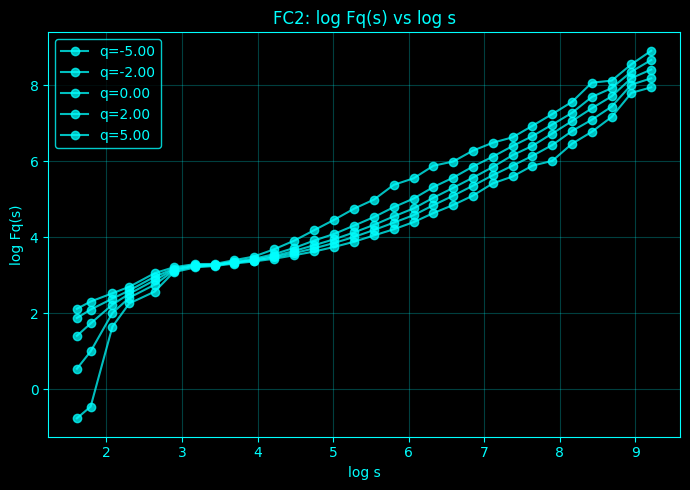

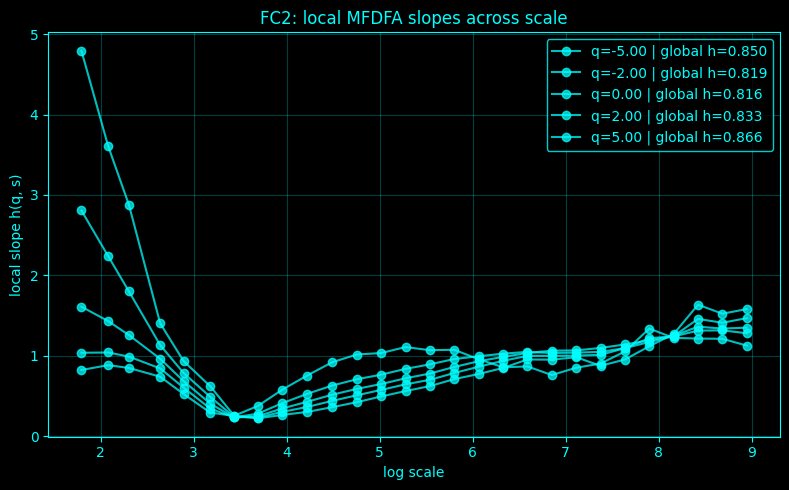

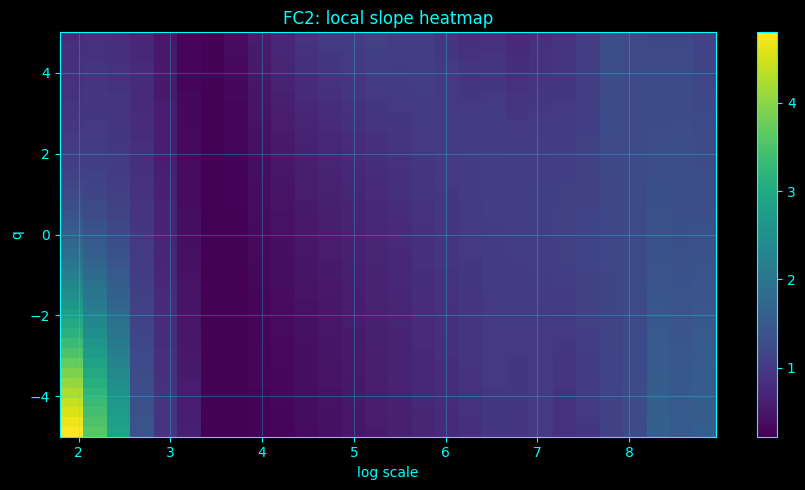

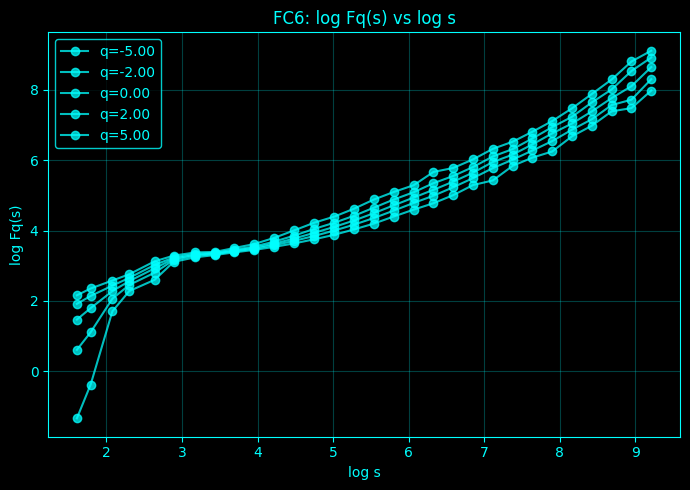

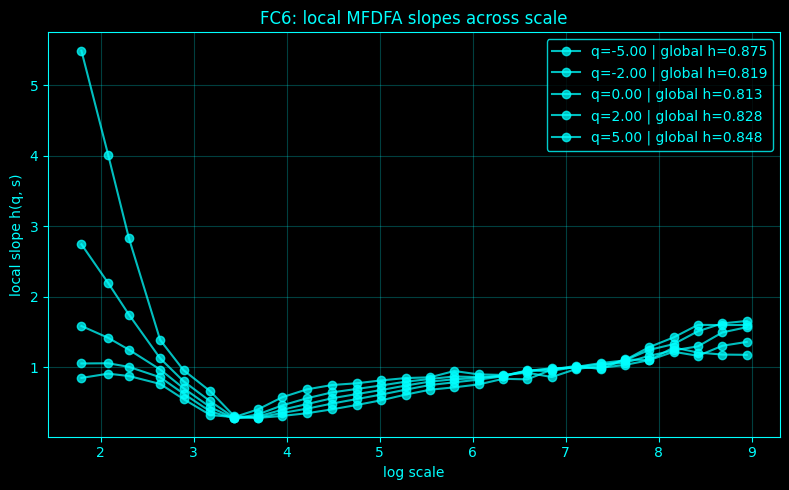

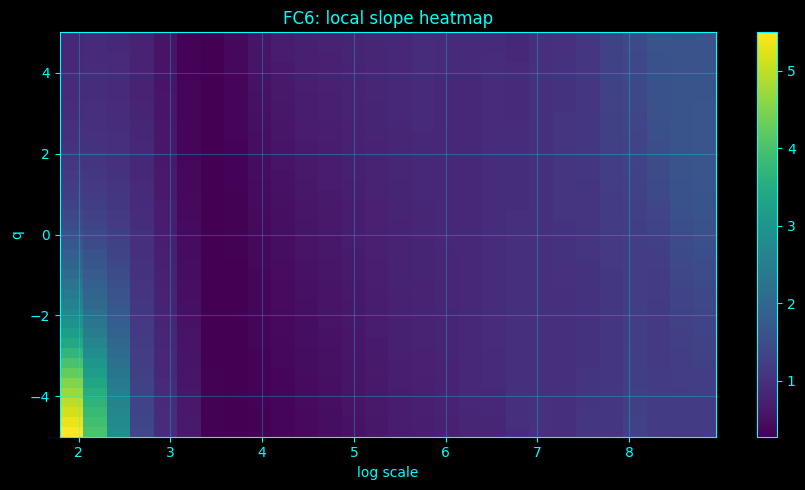

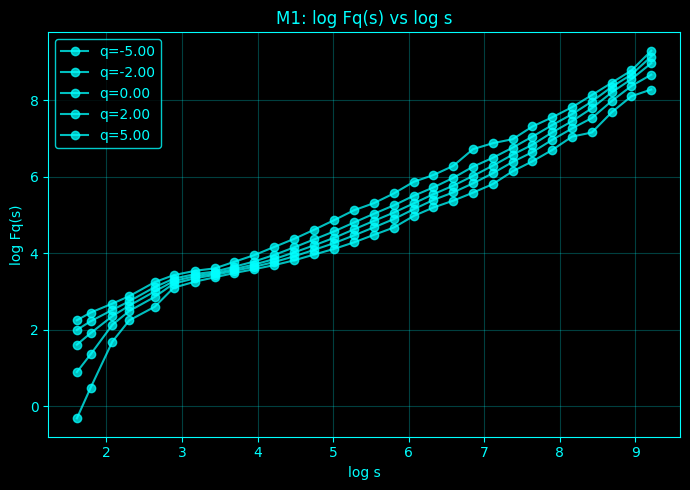

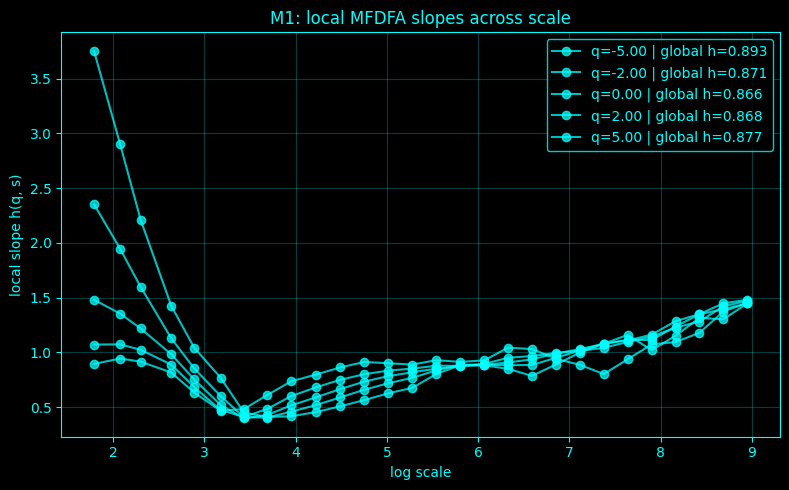

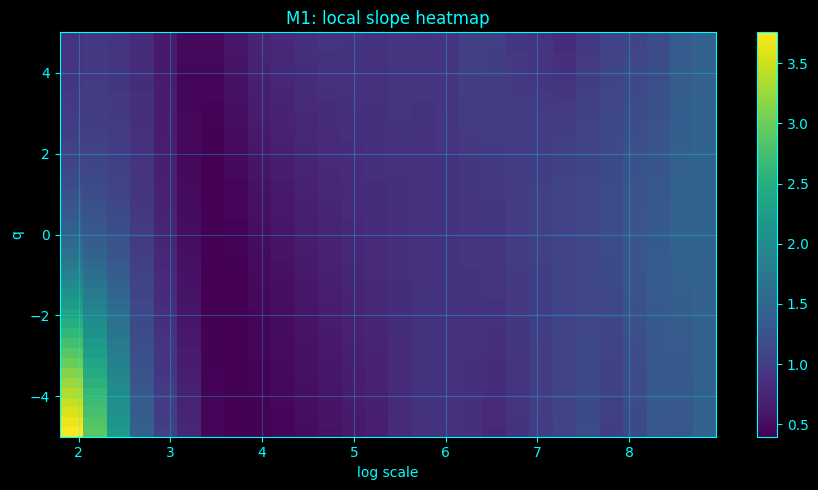

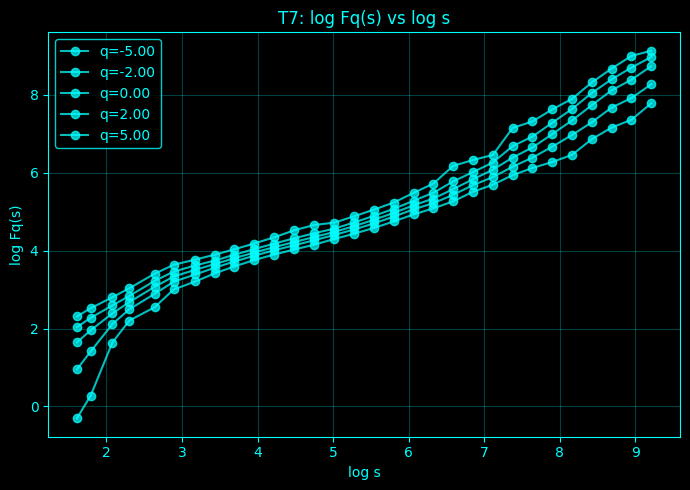

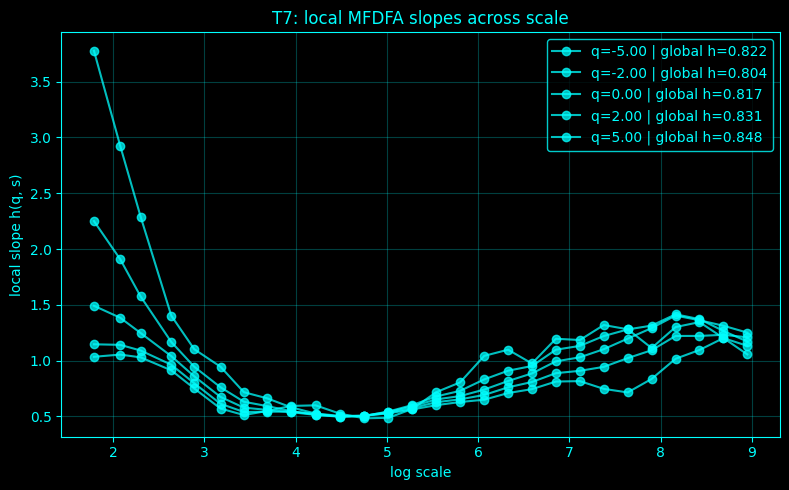

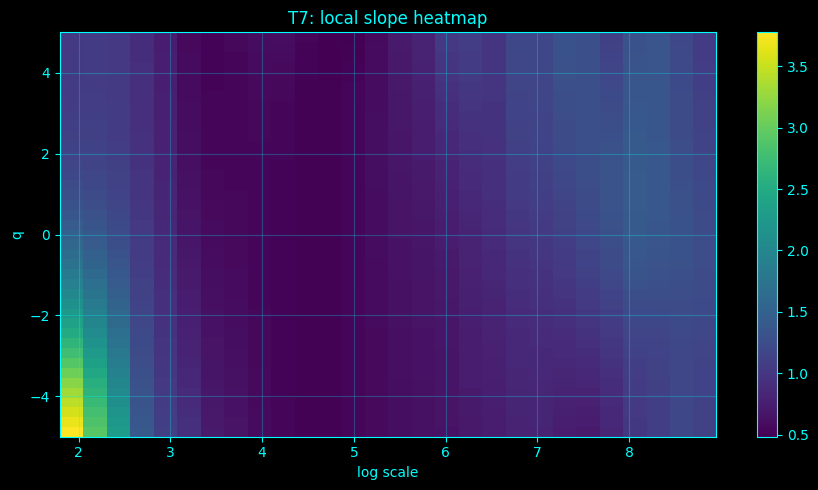

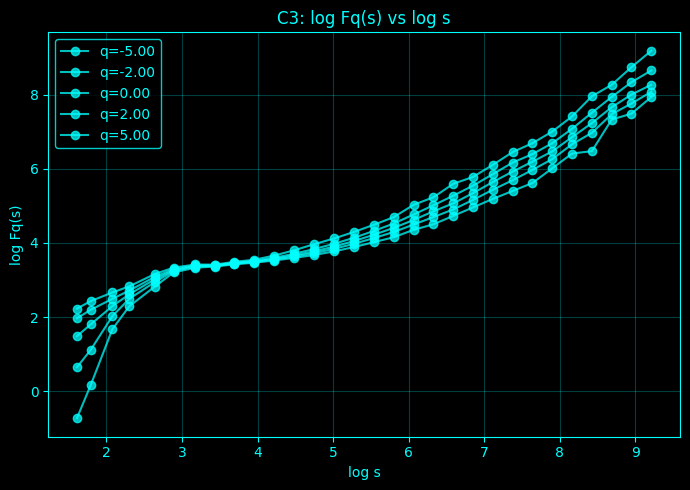

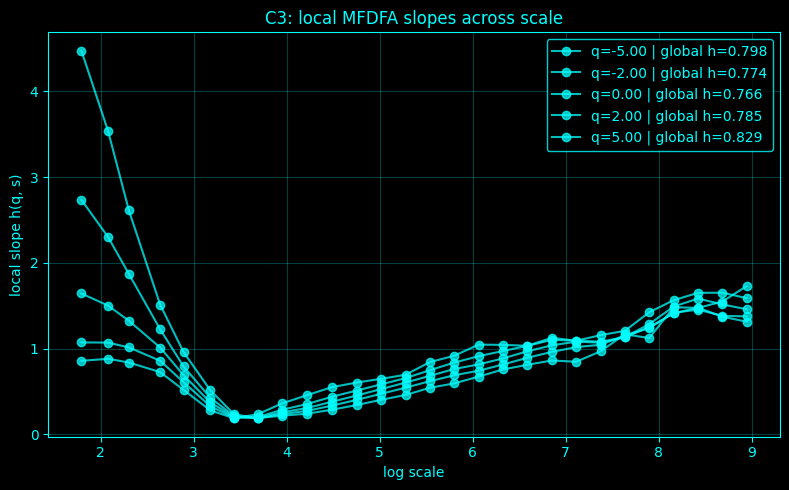

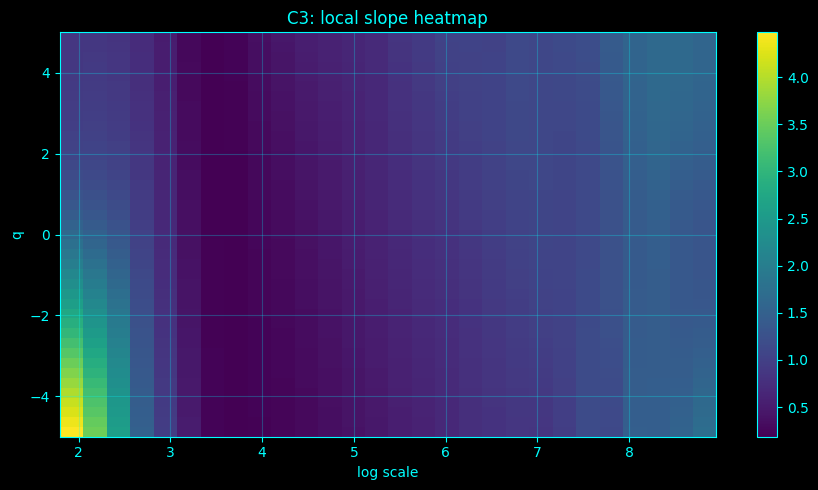

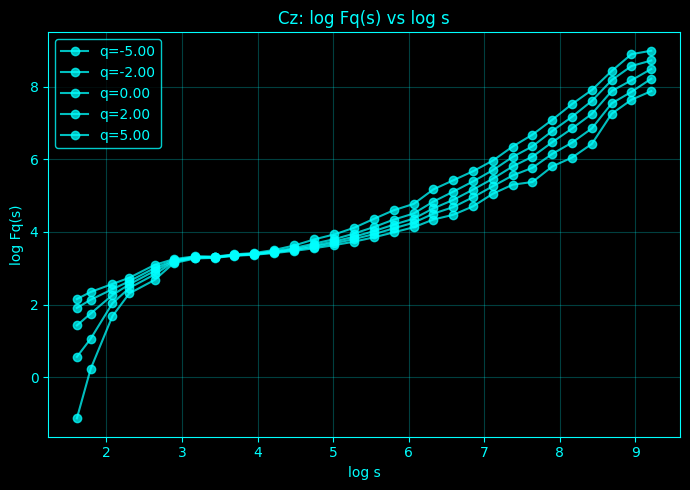

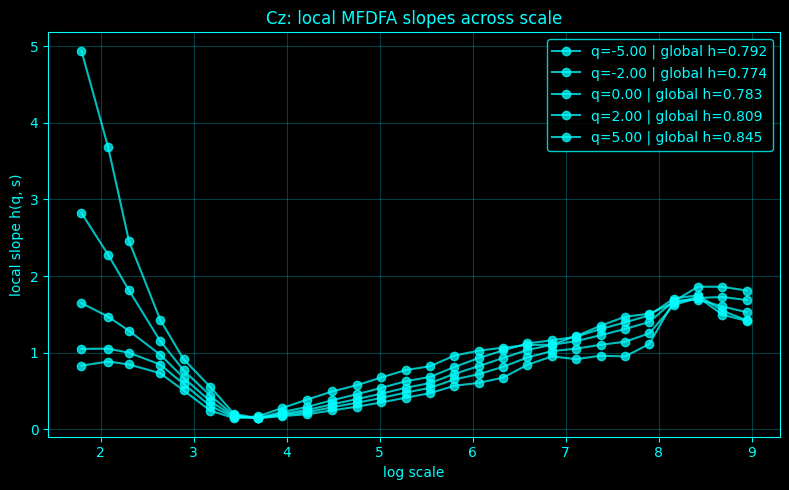

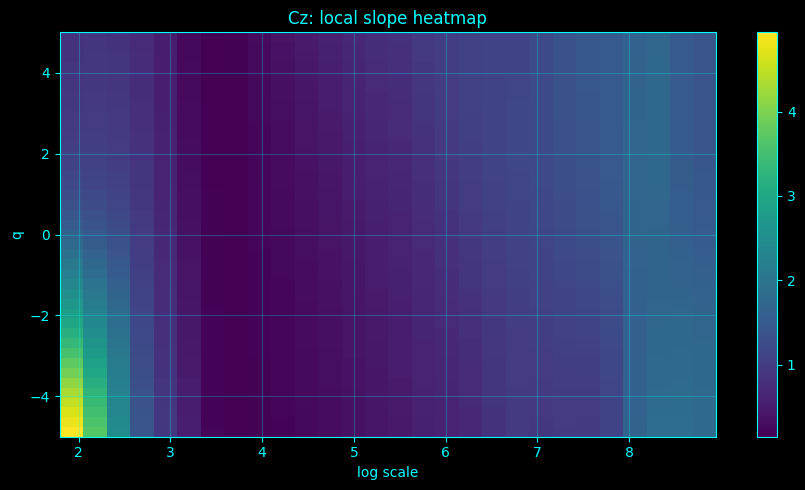

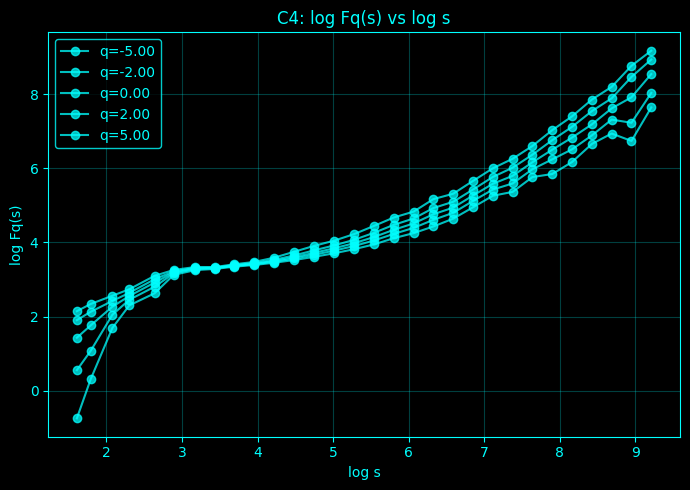

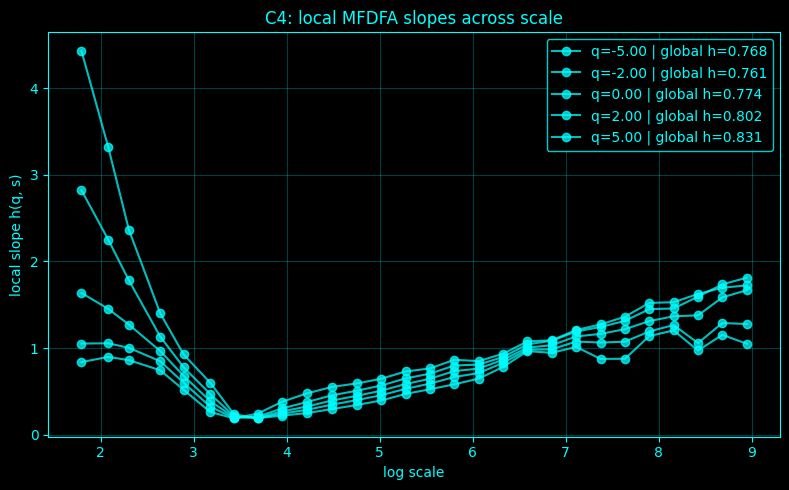

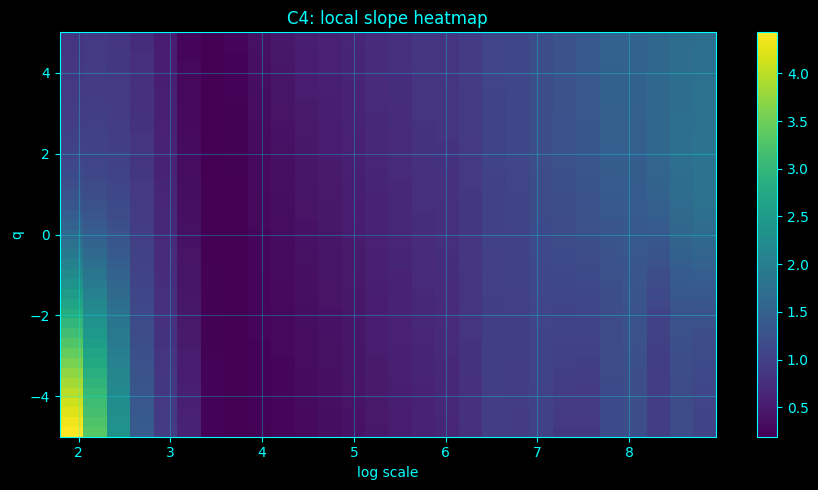

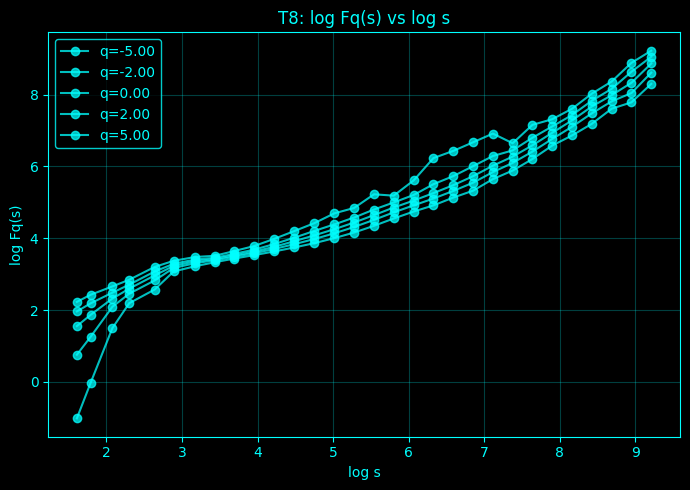

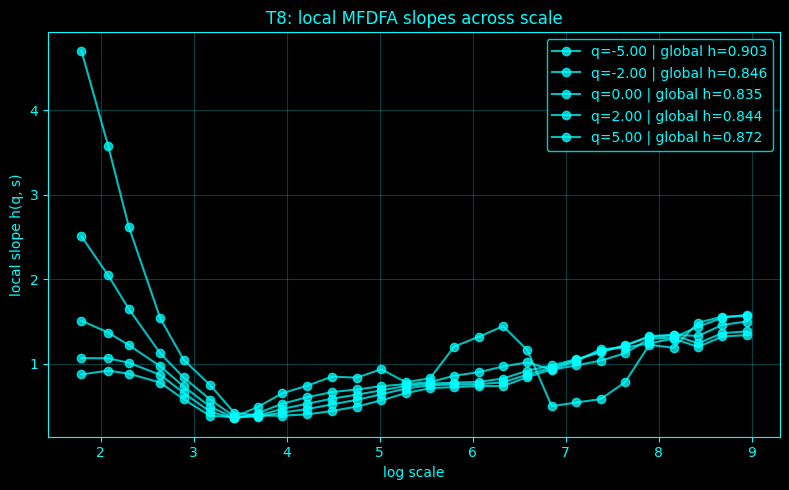

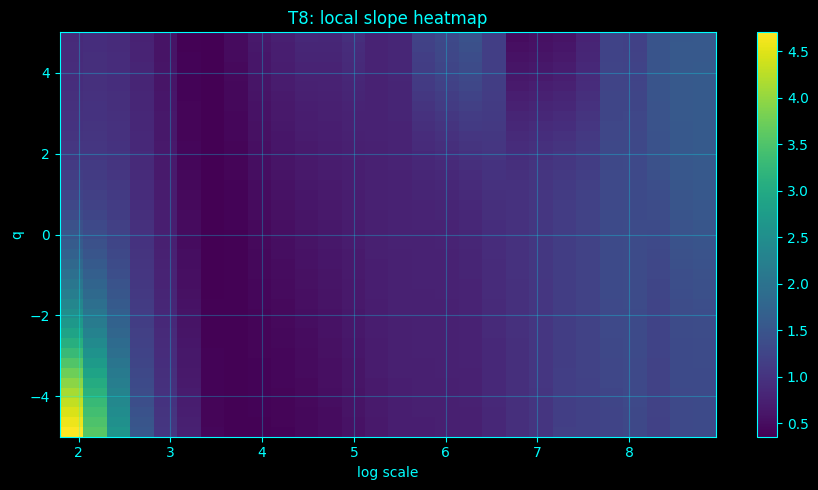

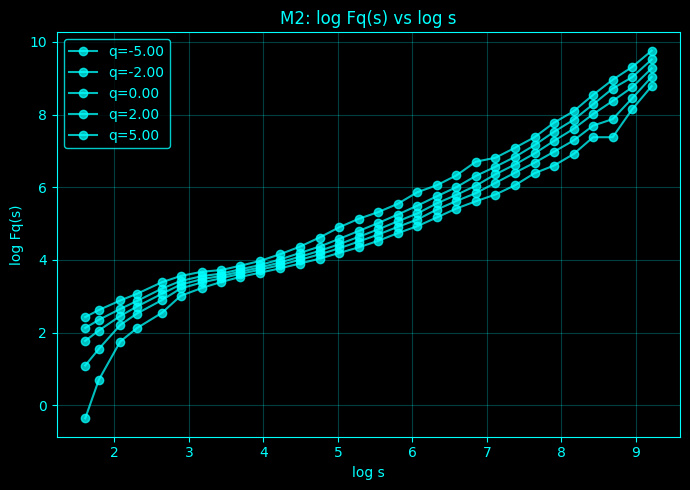

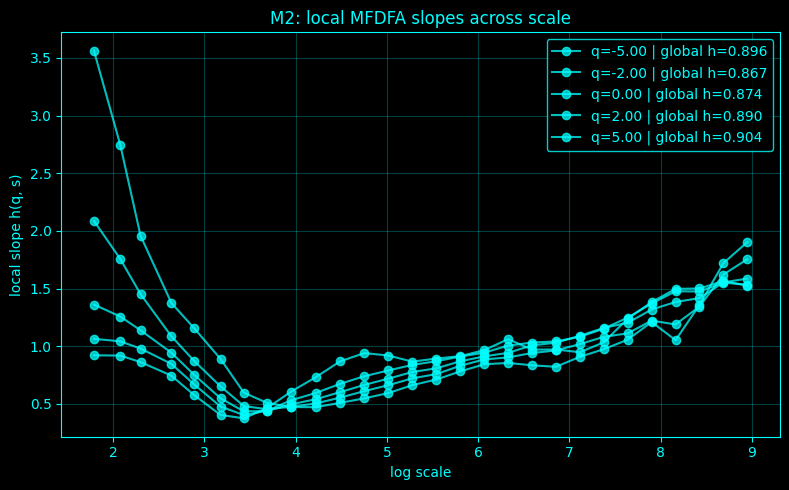

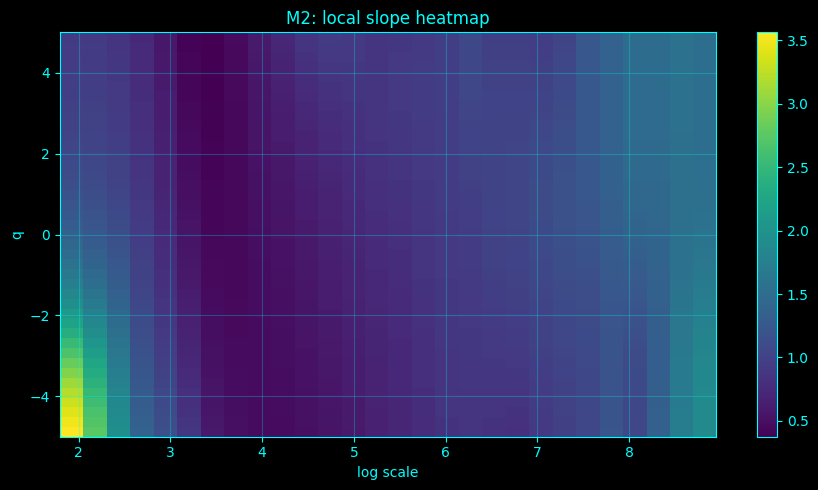

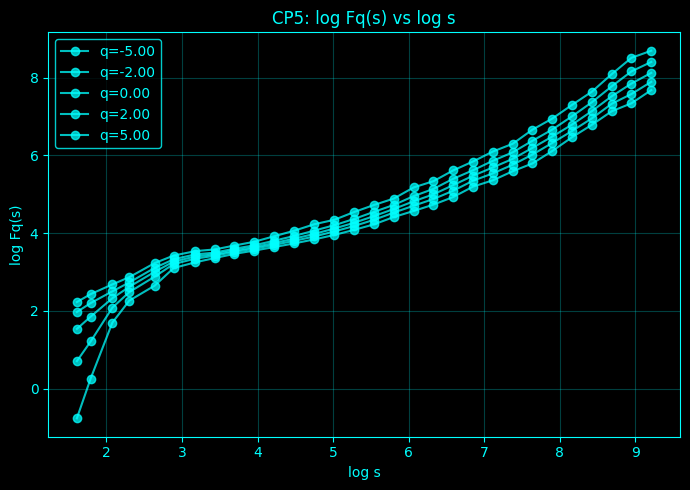

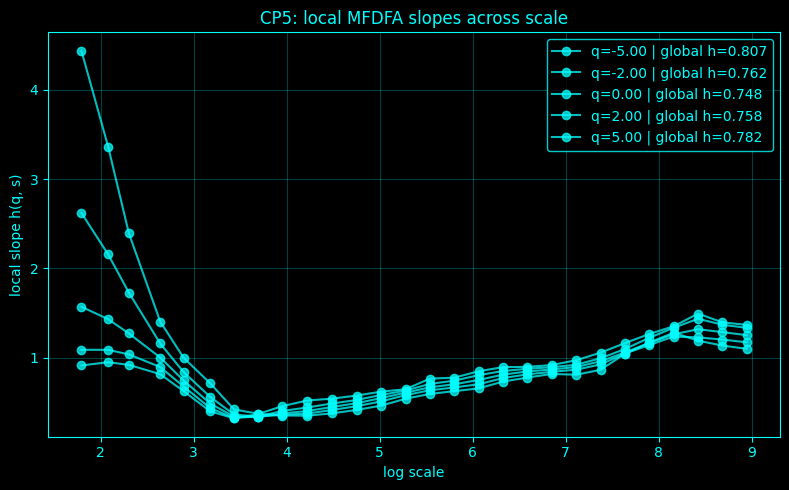

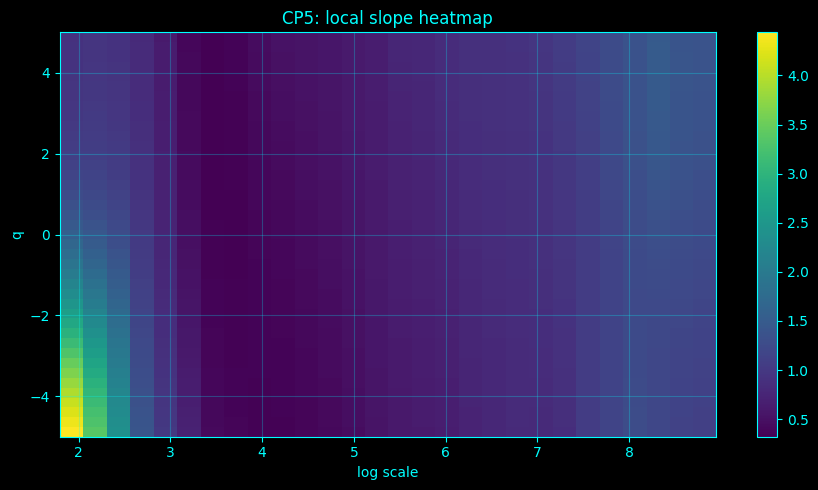

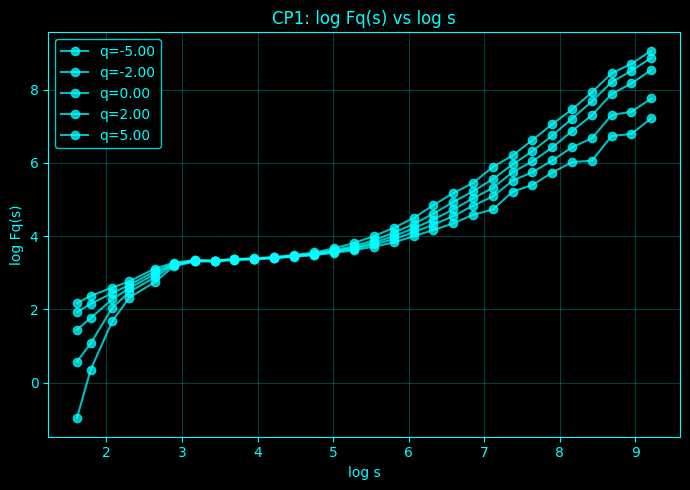

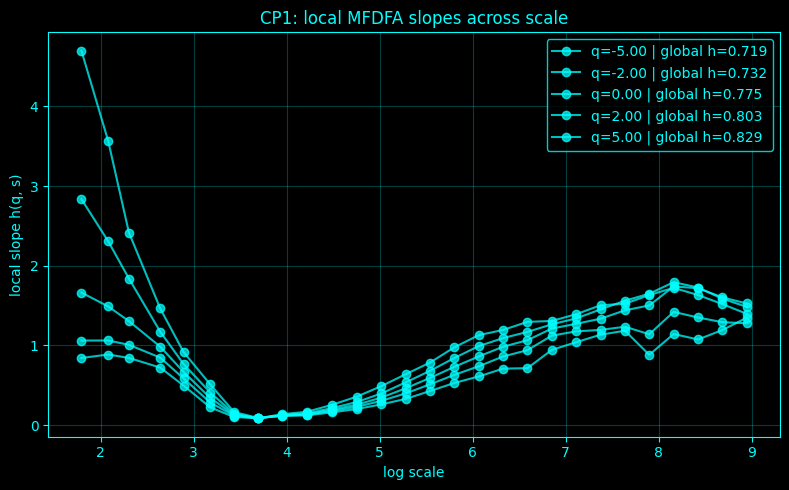

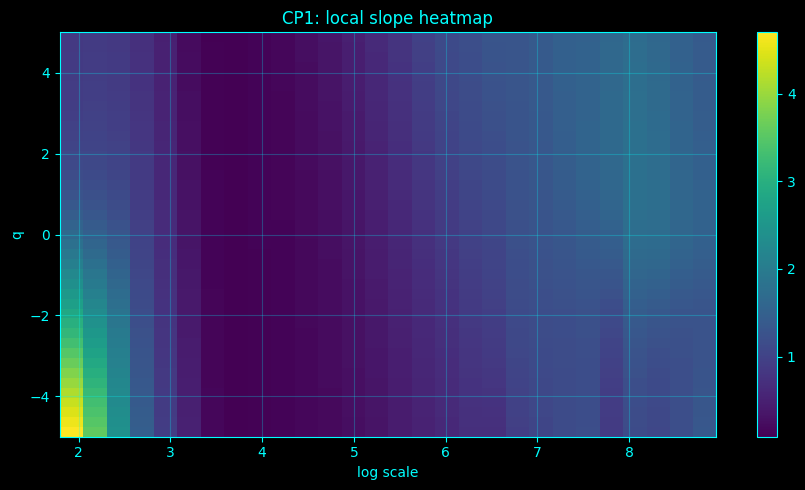

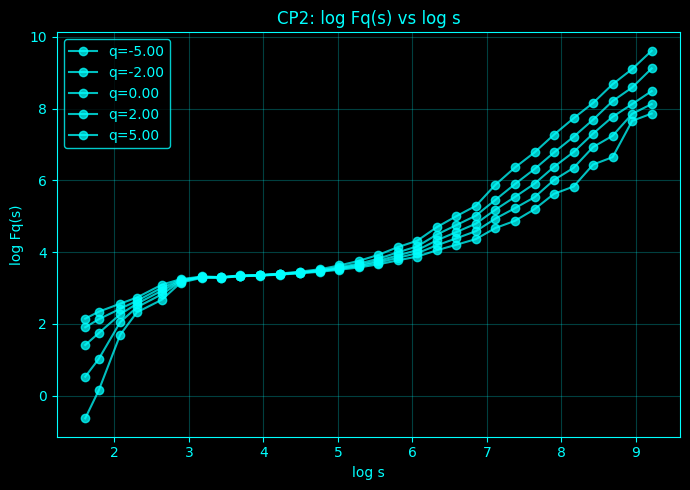

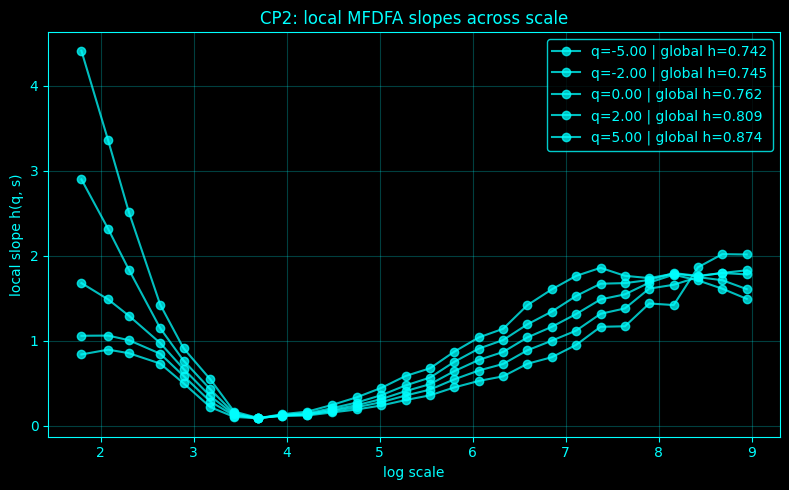

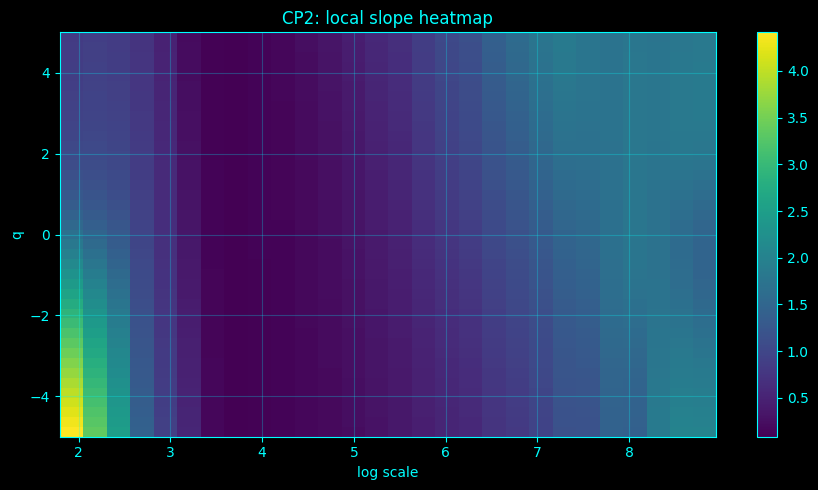

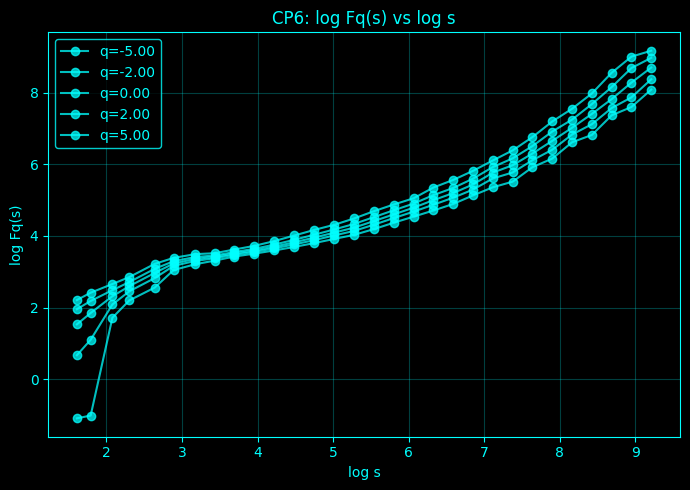

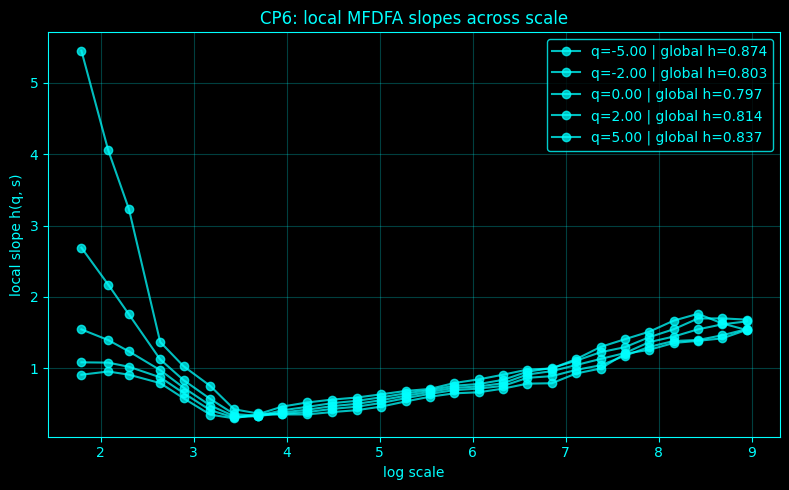

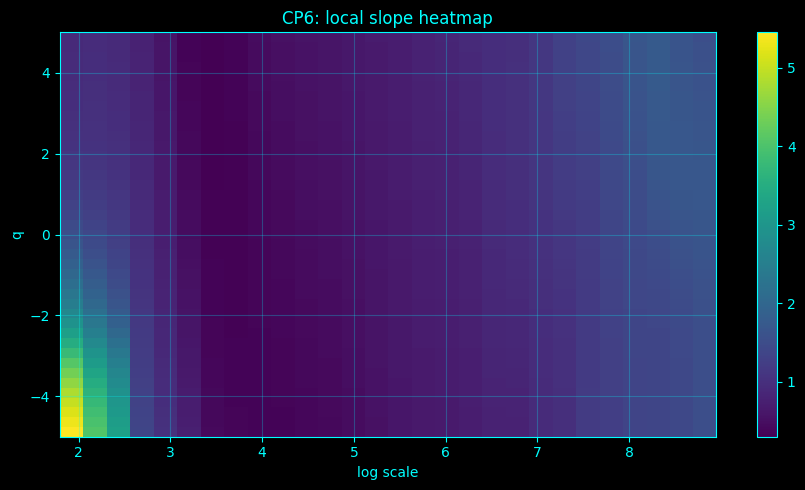

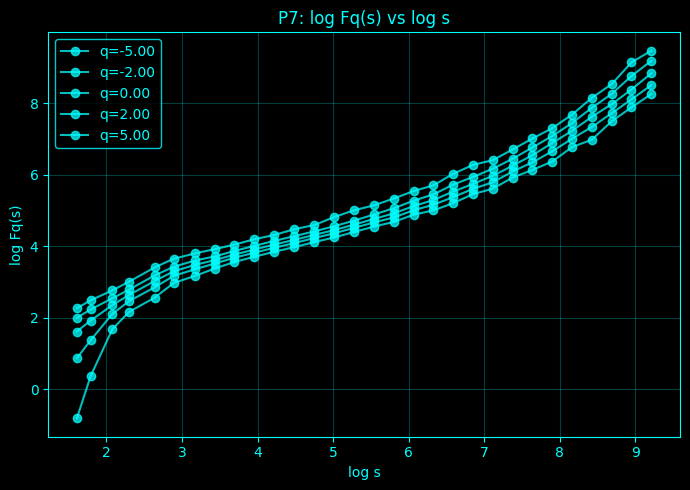

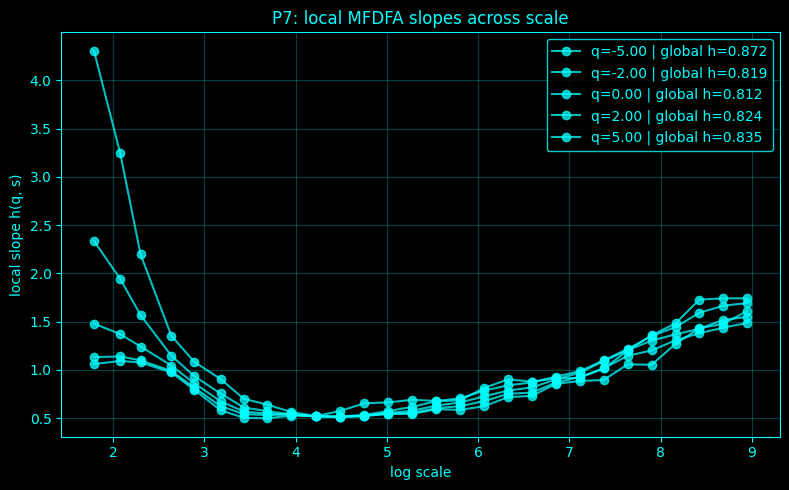

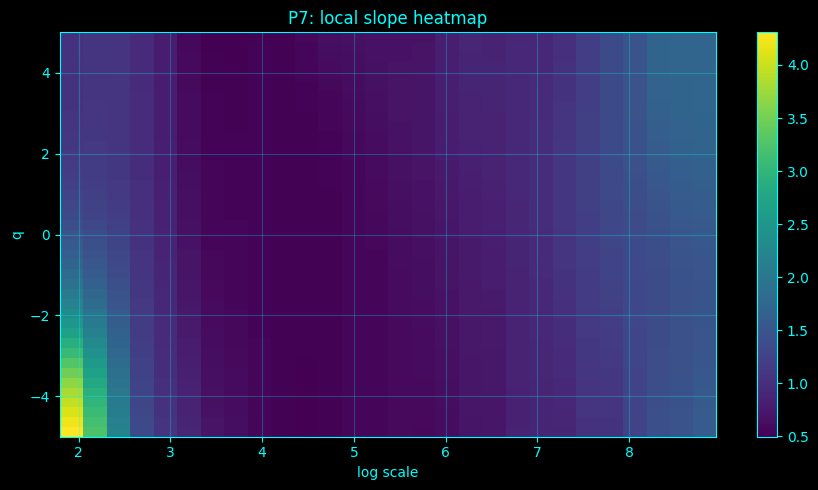

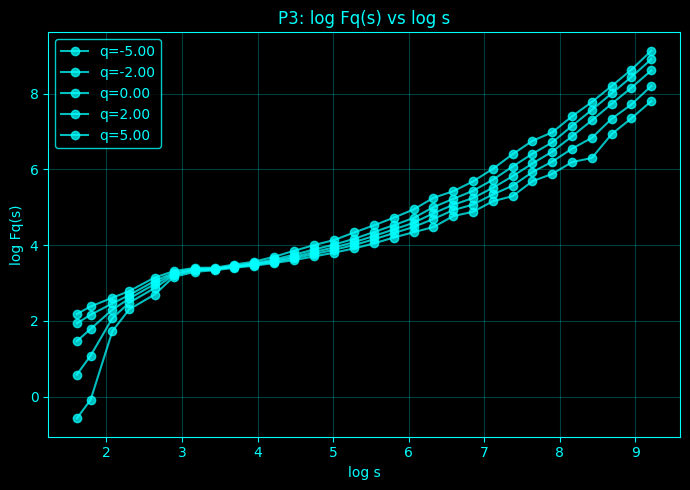

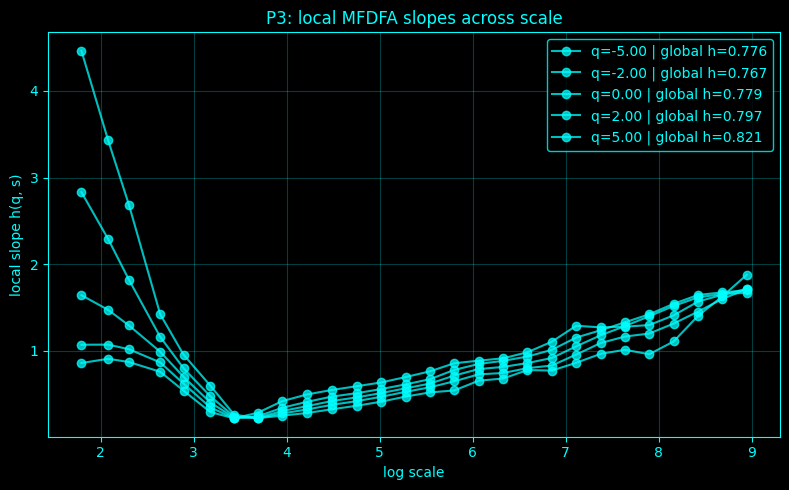

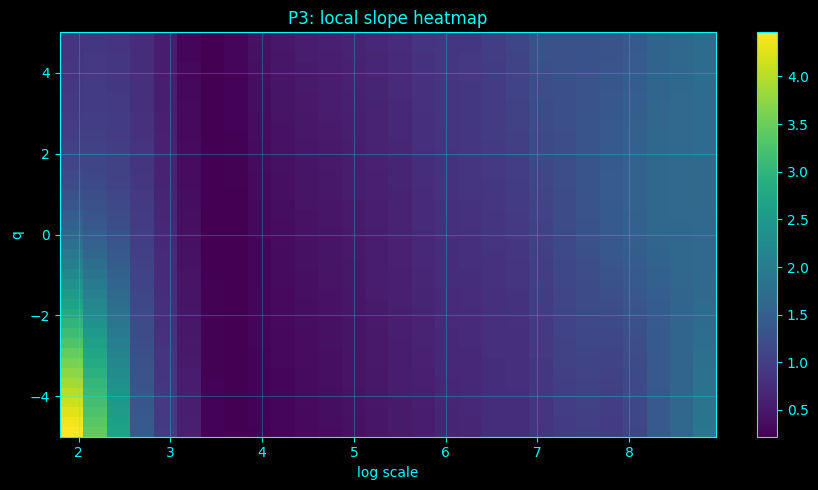

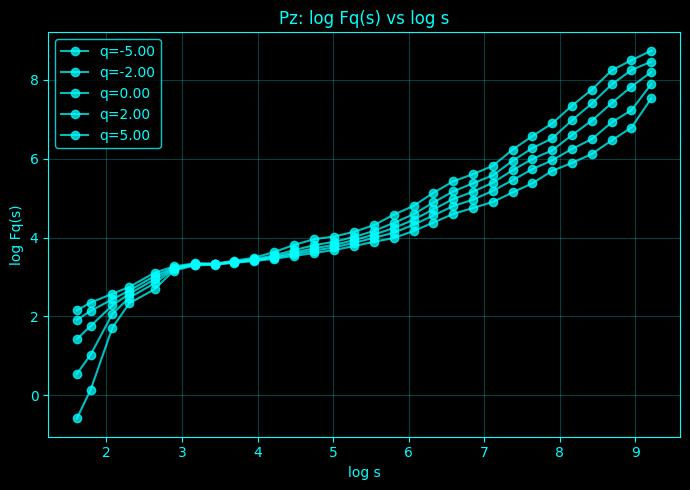

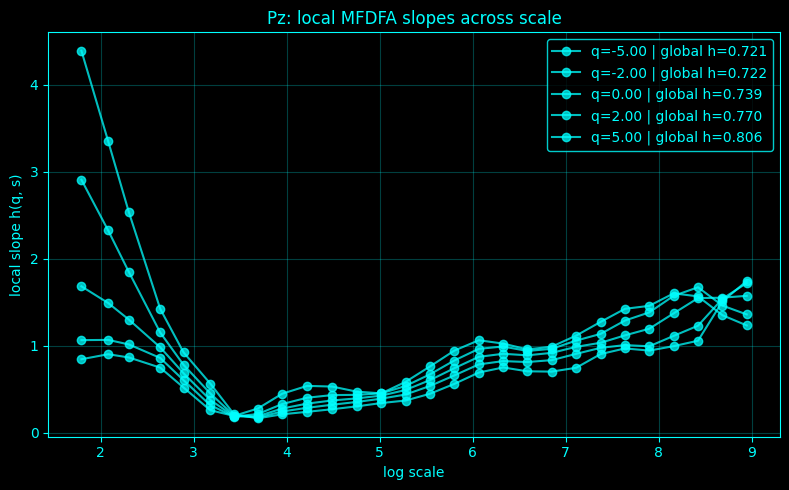

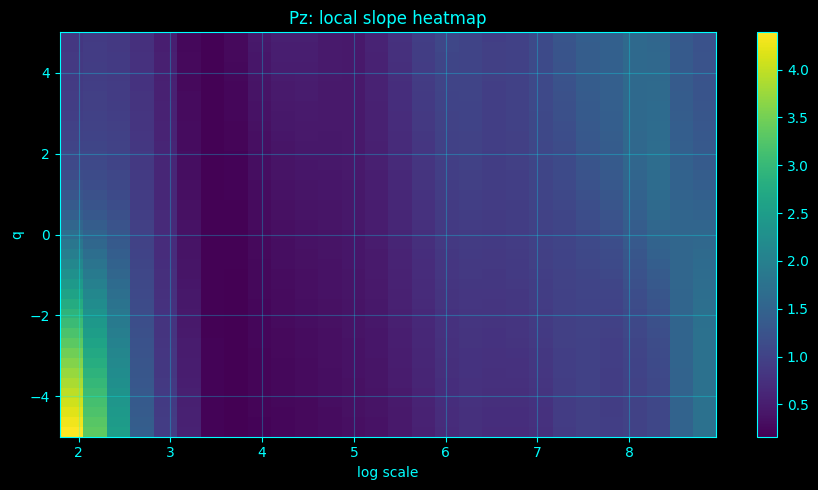

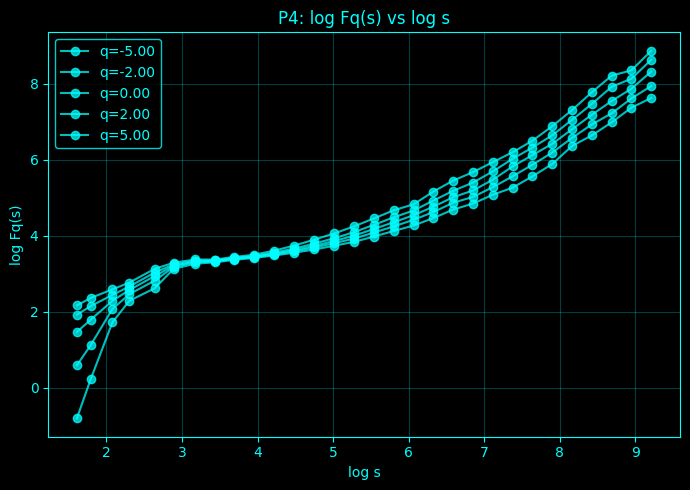

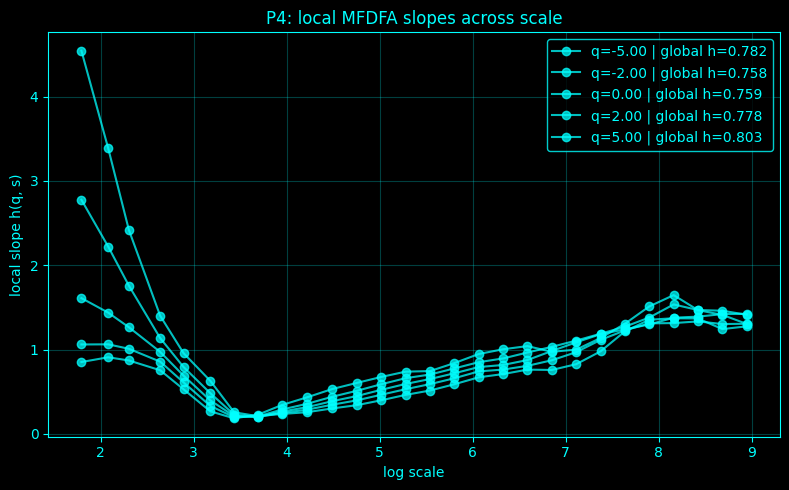

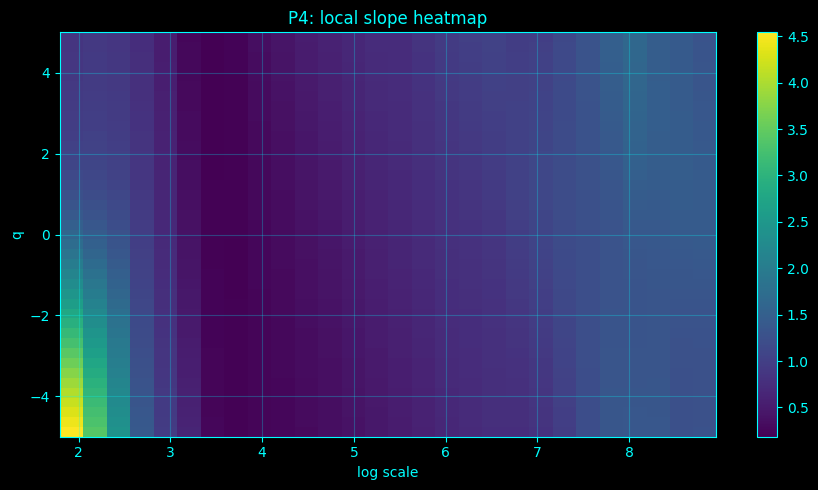

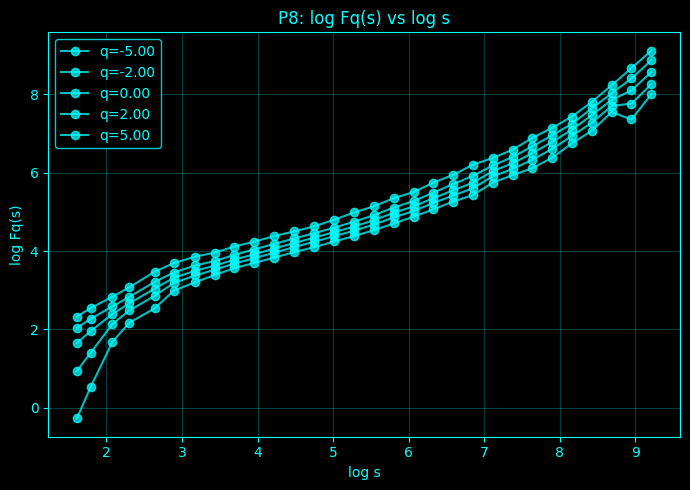

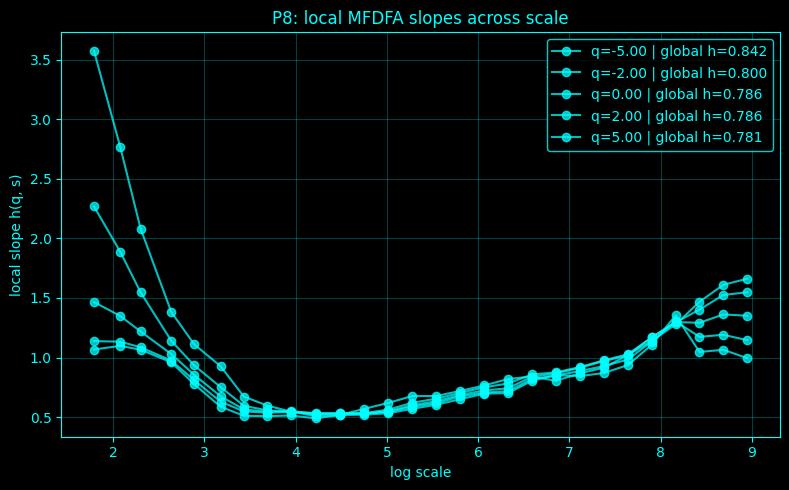

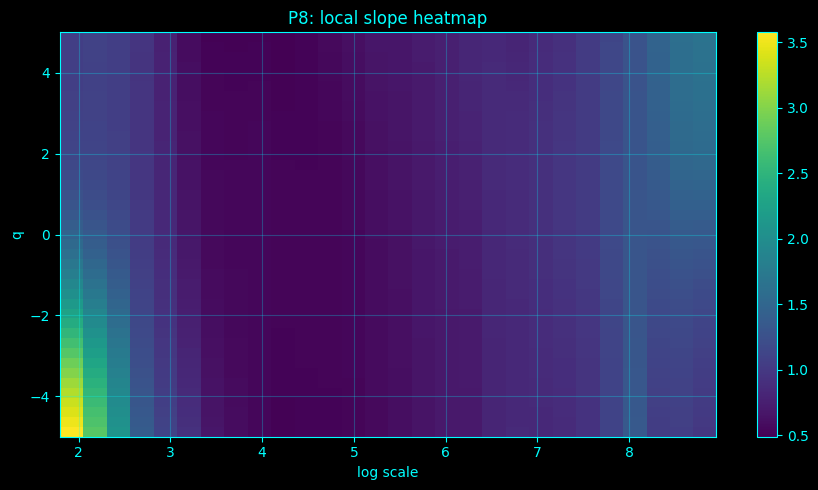

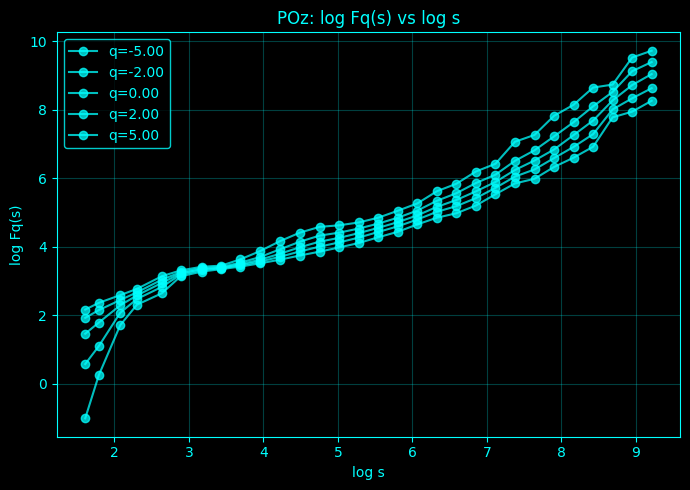

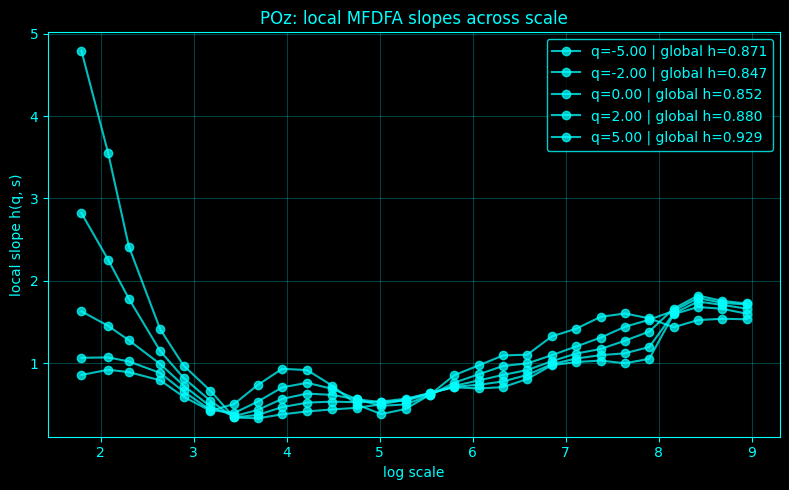

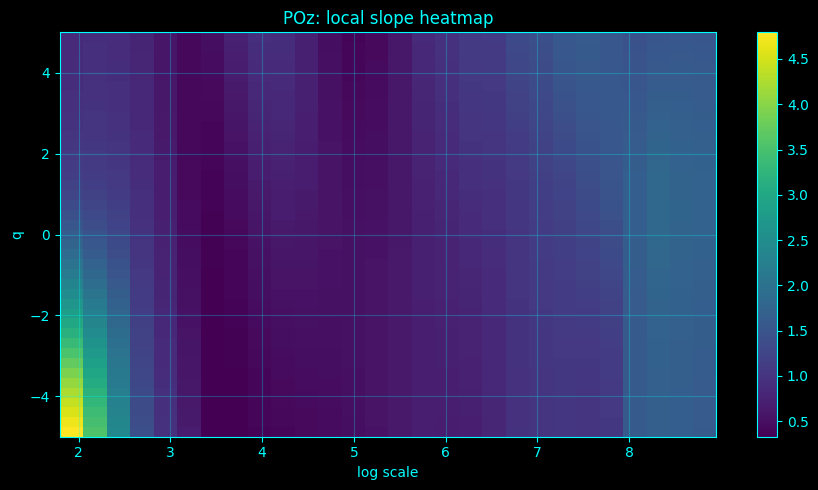

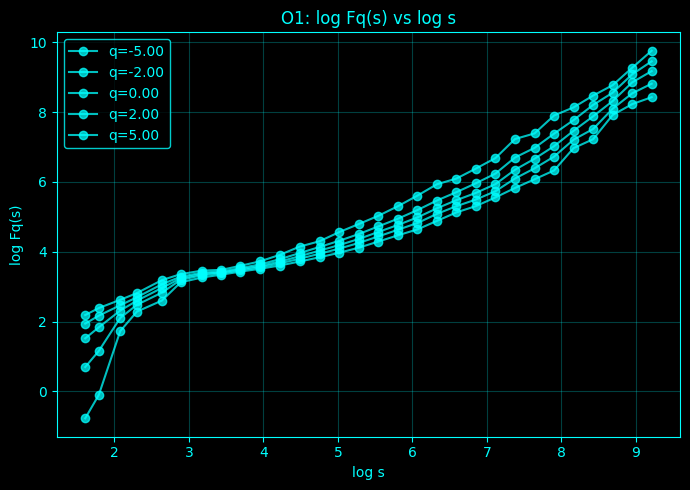

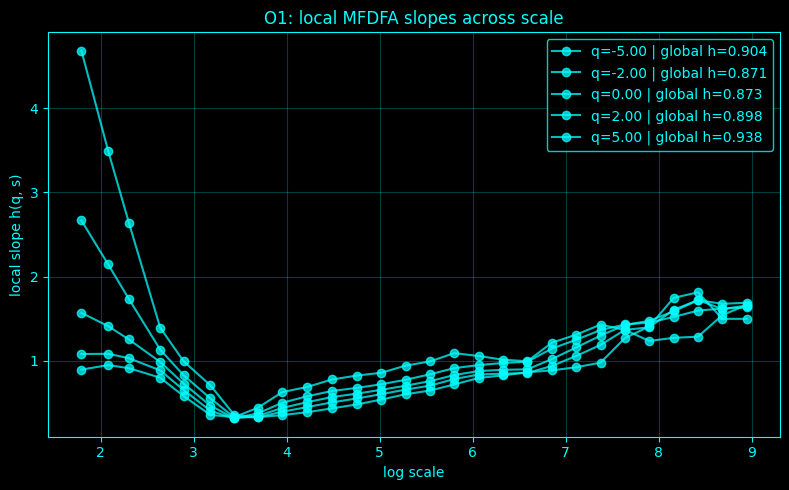

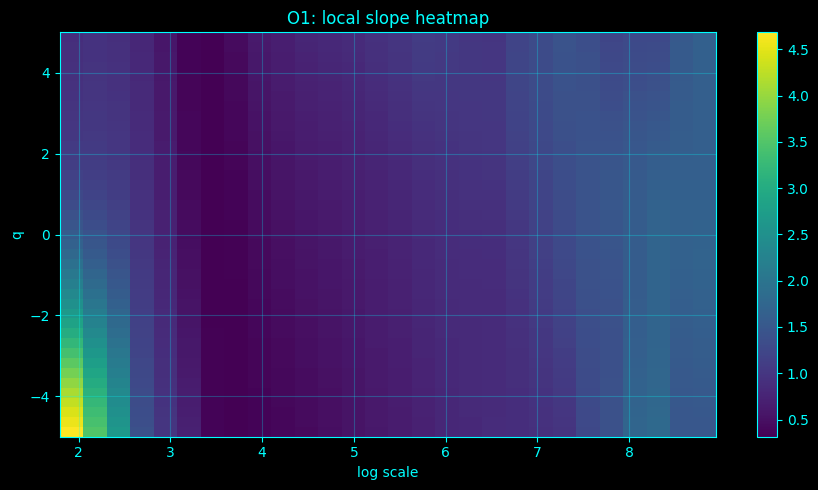

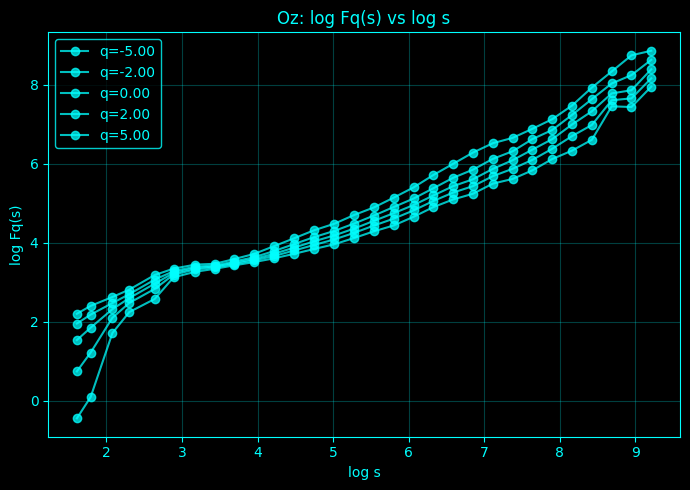

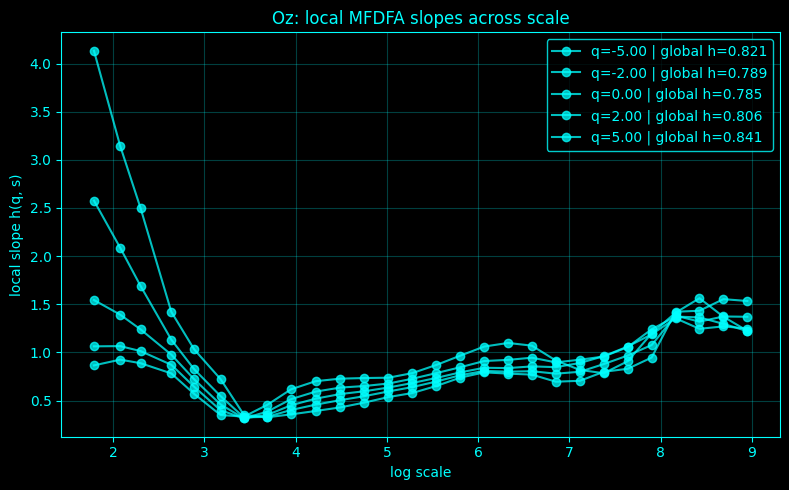

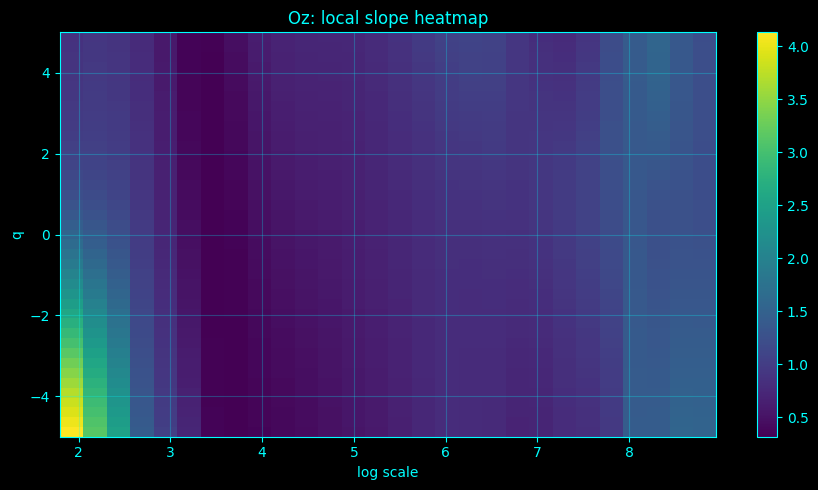

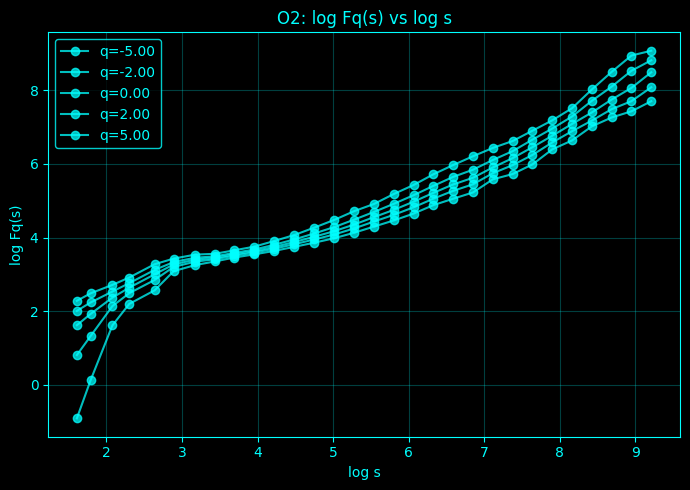

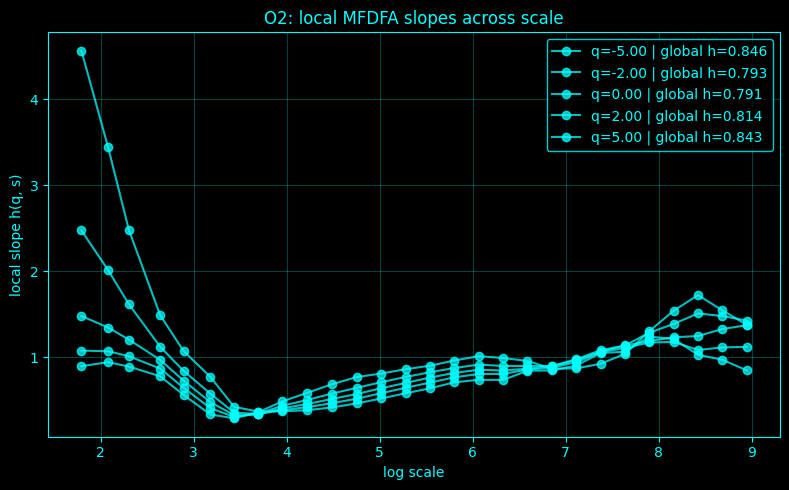

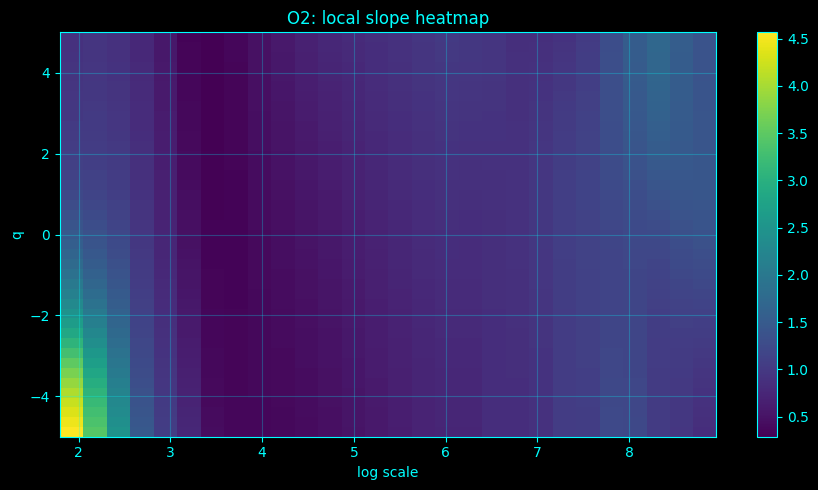


Local slope global summary:
     channel     q  local_h_mean  local_h_std  local_h_min  local_h_max  \
0        Fp1 -5.00      1.163072     0.706375     0.448681     3.587902   
1        Fp1 -4.75      1.155480     0.686537     0.446161     3.497560   
2        Fp1 -4.50      1.147507     0.665191     0.443881     3.398039   
3        Fp1 -4.25      1.139189     0.642416     0.441850     3.289237   
4        Fp1 -4.00      1.130585     0.618383     0.440077     3.171486   
...      ...   ...           ...          ...          ...          ...   
1307      O2  4.00      0.900438     0.345749     0.293459     1.682501   
1308      O2  4.25      0.901066     0.346634     0.292197     1.694632   
1309      O2  4.50      0.901535     0.347410     0.290992     1.705186   
1310      O2  4.75      0.901846     0.348103     0.289834     1.714345   
1311      O2  5.00      0.902002     0.348740     0.288711     1.722273   

      local_h_range  
0          3.139221  
1          3.051399  
2   

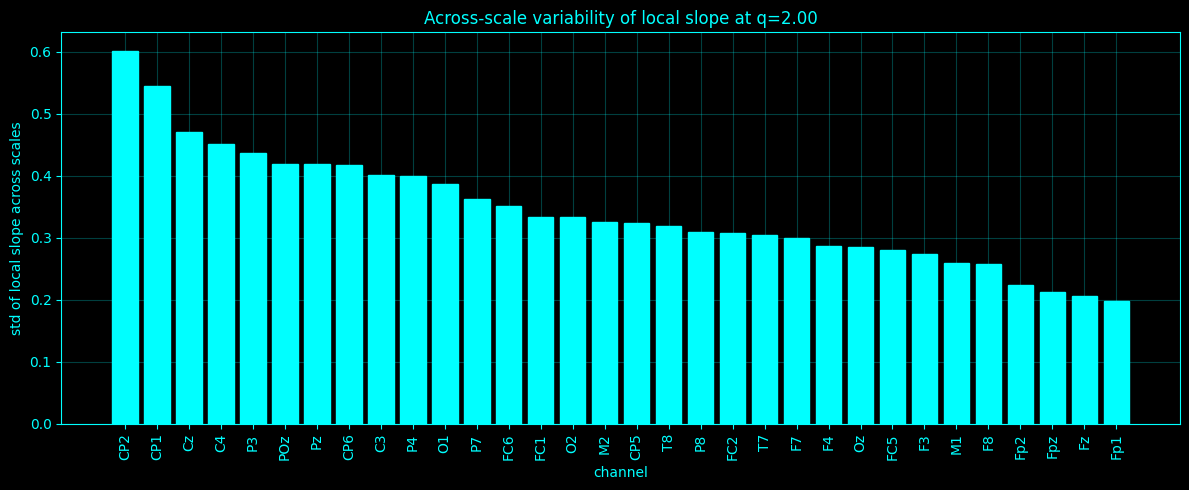

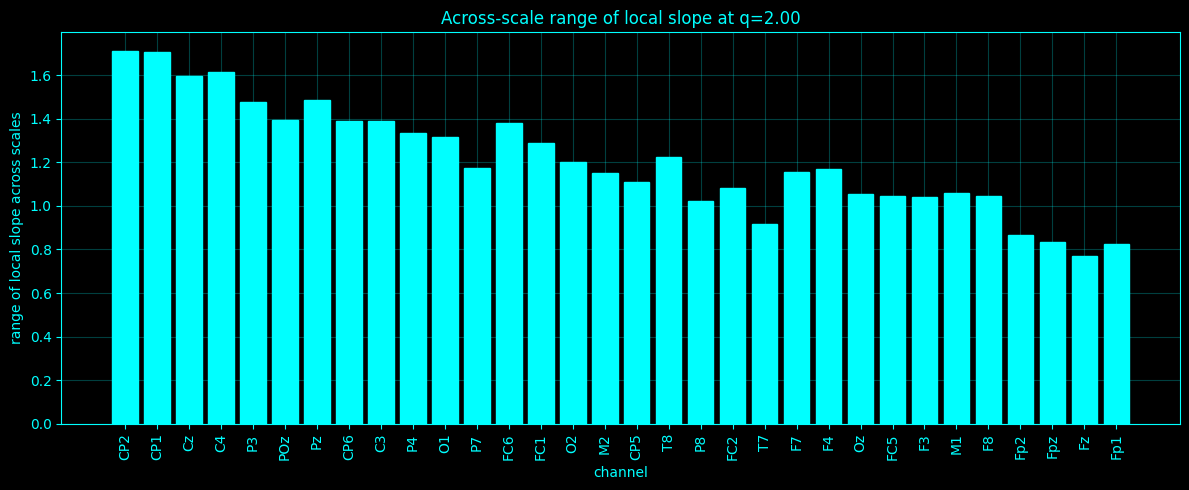


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_local_slope_results
Saved global summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/mfdfa_local_slope_results/local_slope_global_summary.csv


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")
out_dir = os.path.join(base_dir, "mfdfa_local_slope_results")
os.makedirs(out_dir, exist_ok=True)

# Same segment as previous analyses
sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Run all channels; change to ["C3"] if you want lighter output
channels_to_run = eeg_channels.copy()

# Standard q-grid
q_vals = np.linspace(-5, 5, 41)

# q values to display as line plots
q_plot_vals = [-5, -2, 0, 2, 5]

# MFDFA settings
poly_order = 1
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)

# Local slope settings
# sliding regression window length in number of scales
local_window = 5
min_points_fit = 5

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.25, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    x = np.asarray(x, dtype=float)
    N = len(x)

    profile = np.cumsum(x - np.mean(x))
    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        # backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2_segments.append(np.mean((seg - trend) ** 2))

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

def estimate_hq_global(scales, Fq):
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= min_points_fit:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

# -------------------------------------------------------
# LOCAL SLOPE ANALYSIS
# -------------------------------------------------------
def local_slope_mfdfa(scales, Fq, window=5):
    """
    For each q and each center scale index, fit a local slope of:
        log Fq(s) vs log s
    over a moving window of scales.

    Returns:
        centers_log_s : 1D array of log(scale) centers
        local_h       : 2D array shape (n_centers, n_q)
    """
    scales = np.asarray(scales, dtype=float)
    Fq = np.asarray(Fq, dtype=float)

    log_s = np.log(scales)
    n_scales, n_q = Fq.shape

    half = window // 2
    centers = []
    local_h_rows = []

    for i in range(n_scales):
        lo = max(0, i - half)
        hi = min(n_scales, i + half + 1)

        # require exact window length where possible
        if (hi - lo) < max(3, window - 1):
            continue

        xw = log_s[lo:hi]
        row = np.full(n_q, np.nan, dtype=float)

        for qi in range(n_q):
            yw_full = Fq[lo:hi, qi]
            mask = np.isfinite(yw_full) & (yw_full > 0)

            if np.sum(mask) >= 3:
                yw = np.log(yw_full[mask])
                xfit = xw[mask]
                coef = np.polyfit(xfit, yw, 1)
                row[qi] = coef[0]

        centers.append(log_s[i])
        local_h_rows.append(row)

    return np.asarray(centers, dtype=float), np.asarray(local_h_rows, dtype=float)

def summarize_local_slopes(q_vals, local_h, channel_name):
    rows = []

    for qi, q in enumerate(q_vals):
        vals = local_h[:, qi]
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            rows.append({
                "channel": channel_name,
                "q": q,
                "local_h_mean": np.nan,
                "local_h_std": np.nan,
                "local_h_min": np.nan,
                "local_h_max": np.nan,
                "local_h_range": np.nan,
            })
        else:
            rows.append({
                "channel": channel_name,
                "q": q,
                "local_h_mean": float(np.mean(vals)),
                "local_h_std": float(np.std(vals)),
                "local_h_min": float(np.min(vals)),
                "local_h_max": float(np.max(vals)),
                "local_h_range": float(np.max(vals) - np.min(vals)),
            })

    return pd.DataFrame(rows)

# -------------------------------------------------------
# LOAD EEG SEGMENT FROM PATH
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channels)}

# map q values to nearest indices for plotting
q_plot_idx = []
for q in q_plot_vals:
    q_plot_idx.append(int(np.argmin(np.abs(q_vals - q))))

# -------------------------------------------------------
# RUN LOCAL SLOPE ANALYSIS
# -------------------------------------------------------
all_summary_rows = []

for channel_name in channels_to_run:
    if channel_name not in channel_to_idx:
        print(f"Skipping unknown channel: {channel_name}")
        continue

    ch_idx = channel_to_idx[channel_name]
    x = EEG_segment[:, ch_idx].astype(float)

    # MFDFA
    scales_out, Fq = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq_global = estimate_hq_global(scales_out, Fq)

    # Local slopes
    centers_log_s, local_h = local_slope_mfdfa(scales_out, Fq, window=local_window)
    centers_s = np.exp(centers_log_s)

    # Per-channel summary
    summary_df = summarize_local_slopes(q_vals, local_h, channel_name)
    all_summary_rows.append(summary_df)

    # Save numerical output
    npz_path = os.path.join(out_dir, f"{channel_name}_local_slope_mfdfa.npz")
    np.savez(
        npz_path,
        channel=channel_name,
        start_time=start_time,
        end_time=end_time,
        sampling_rate=sampling_rate,
        scales=scales_out,
        q_vals=q_vals,
        Fq=Fq,
        hq_global=hq_global,
        centers_log_s=centers_log_s,
        centers_s=centers_s,
        local_h=local_h,
        local_window=local_window,
    )

    summary_csv_path = os.path.join(out_dir, f"{channel_name}_local_slope_summary.csv")
    summary_df.to_csv(summary_csv_path, index=False)

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------

    # 1) logFq vs logs for selected q
    fig, ax = plt.subplots(figsize=(7, 5), facecolor=BG)
    style_ax(ax)

    for qi in q_plot_idx:
        ax.plot(
            np.log(scales_out),
            np.log(Fq[:, qi]),
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=f"q={q_vals[qi]:.2f}"
        )

    ax.set_title(f"{channel_name}: log Fq(s) vs log s")
    ax.set_xlabel("log s")
    ax.set_ylabel("log Fq(s)")
    ax.legend()

    fig1_path = os.path.join(out_dir, f"{channel_name}_logFq_selected_q.png")
    plt.tight_layout()
    plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # 2) local slope curves for selected q
    fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
    style_ax(ax)

    for qi in q_plot_idx:
        ax.plot(
            centers_log_s,
            local_h[:, qi],
            marker='o',
            color=ACCENT,
            markerfacecolor=ACCENT,
            markeredgecolor=ACCENT,
            alpha=0.75,
            label=f"q={q_vals[qi]:.2f} | global h={hq_global[qi]:.3f}"
        )

    ax.set_title(f"{channel_name}: local MFDFA slopes across scale")
    ax.set_xlabel("log scale")
    ax.set_ylabel("local slope h(q, s)")
    ax.legend()

    fig2_path = os.path.join(out_dir, f"{channel_name}_local_slope_selected_q.png")
    plt.tight_layout()
    plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # 3) heatmap of local slopes: q x scale
    fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(
        local_h.T,
        aspect="auto",
        origin="lower",
        extent=[centers_log_s.min(), centers_log_s.max(), q_vals.min(), q_vals.max()]
    )

    ax.set_title(f"{channel_name}: local slope heatmap")
    ax.set_xlabel("log scale")
    ax.set_ylabel("q")

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)

    fig3_path = os.path.join(out_dir, f"{channel_name}_local_slope_heatmap.png")
    plt.tight_layout()
    plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# SAVE GLOBAL SUMMARY
# -------------------------------------------------------
global_summary_df = pd.concat(all_summary_rows, ignore_index=True)
global_summary_csv = os.path.join(out_dir, "local_slope_global_summary.csv")
global_summary_df.to_csv(global_summary_csv, index=False)

print("\nLocal slope global summary:")
print(global_summary_df)

# -------------------------------------------------------
# ACROSS-CHANNEL SUMMARY PLOTS
# -------------------------------------------------------
# 1) local slope variability by channel for q = 2
q_target = 2.0
q_idx = int(np.argmin(np.abs(q_vals - q_target)))
q_actual = q_vals[q_idx]

var_df = global_summary_df[np.isclose(global_summary_df["q"], q_actual)].copy()
var_df = var_df.sort_values("local_h_std", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(var_df["channel"], var_df["local_h_std"], color=ACCENT, edgecolor=ACCENT)
ax.set_title(f"Across-scale variability of local slope at q={q_actual:.2f}")
ax.set_xlabel("channel")
ax.set_ylabel("std of local slope across scales")
ax.tick_params(axis='x', rotation=90)

fig4_path = os.path.join(out_dir, f"local_slope_std_q_{q_actual:.2f}.png")
plt.tight_layout()
plt.savefig(fig4_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# 2) local slope range by channel for q = 2
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.bar(var_df["channel"], var_df["local_h_range"], color=ACCENT, edgecolor=ACCENT)
ax.set_title(f"Across-scale range of local slope at q={q_actual:.2f}")
ax.set_xlabel("channel")
ax.set_ylabel("range of local slope across scales")
ax.tick_params(axis='x', rotation=90)

fig5_path = os.path.join(out_dir, f"local_slope_range_q_{q_actual:.2f}.png")
plt.tight_layout()
plt.savefig(fig5_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved global summary CSV: {global_summary_csv}")